#🍩Slot token classification (BIO) 구현

**Bio란?**

- **B (Begin):** 슬롯 정보가 **시작**되는 첫 번째 단어에 붙입니다.
- **I (Inside):** 두 단어 이상으로 이루어진 정보에서 **두 번째 단어부터** 끝까지 붙입니다.
- **O (Outside):** 우리가 추출할 정보와 **상관없는** 일반 단어(조사, 서술어 등)에 붙입니다.

**사용하면 좋은 이유**
1. 여러 단어로 된 슬롯을 하나로 묶어줌 (가장 중요!)
퍼스트 핀 임계값, 퍼스트핀임계값 -> firstPinThreshold 임을 앎. 하나의 덩어리로 이해

2. 연속된 같은 종류의 슬롯을 구분해줌  
lga bga 창 둘 다 열어줘 -> 서로 다른 두 개의 창을 원하는구나  

3. lgaa 같은 오타가 나거나 어순이 바뀌어도 정확한 슬롯의 범위를 찾아낼 수 있는 것
---
bio 안 좋은 점, 문장에서 추출이라서 X, 논문에서는 non categorical의 경우 이 방식을 사용했었음.  
문제!  
1. window에 따라 후보 달라짐
2. 일부 슬롯은 조건부 required  
논문은 객관식 방식을 (slot 주고 거기서 맞춰라) 식이니 이게 우리한테 더 맞음

# 1. 데이터 만들기(800~1000개)
- 슬롯 16개  
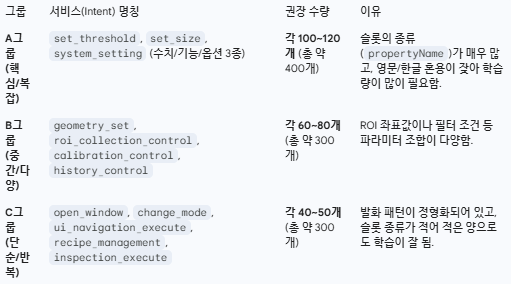  

system_setting_total: 400~450  
set_threshold: 120  
geometry_set: 100  
set_size: 80  
history / calibration: 100  
나머지 단순 서비스: 150  

## bio

In [ ]:
import random
import json
from itertools import product
import re

# -----------------------------
# 1. 슬롯 정의 (JSON 기반)
# -----------------------------

window_map = {
    "lga": ["lga", "엘지에이"],
    "qfn": ["qfn", "큐에프엔"],
    "bga": ["bga", "비지에이"],
    "mapping": ["mapping", "매핑"],
    "calibration": ["calibration", "캘리브레이션", "캘리"]
}

threshold_types_by_window = {
    "lga": [
        "PackageThreshold", "FirstPinThreshold", "MultiPadThreshold",
        "LeadThreshold", "ScratchThreshold", "ForeignMaterialThreshold",
        "ContaminationThreshold", "OutlineThreshold", "RejectMarkThreshold"
    ],
    "qfn": [
        "PackageThreshold", "FirstPinThreshold", "PadThreshold",
        "LeadThreshold", "ScratchThreshold", "ForeignMaterialThreshold",
        "ContaminationThreshold", "OutlineThreshold", "RejectMarkThreshold"
    ],
    "bga": [
        "PackageThreshold", "FirstPinThreshold", "PatternThreshold",
        "BallThreshold", "ScratchThreshold", "ForeignMaterialThreshold",
        "ContaminationThreshold", "OutlineThreshold", "RejectMarkThreshold"
    ],
    "mapping": [
        "MarkThreshold", "ScratchThreshold",
        "ForeignMaterialThreshold", "ContaminationThreshold",
        "OutlineThreshold", "RejectMarkThreshold"
    ]
}

# threshold 한글 동의어
threshold_korean_map = {
    "PackageThreshold": ["패키지 임계값", "패키지 임계", "패키지"],
    "FirstPinThreshold": ["퍼스트핀 임계값", "첫핀 임계"],
    "MultiPadThreshold": ["멀티패드 임계값", "멀티 패드 임계"],
    "LeadThreshold": ["리드 임계값", "리드 임계"],
    "ScratchThreshold": ["스크래치 임계값", "긁힘 임계", "스크래치 임계"],
    "ForeignMaterialThreshold": ["이물 임계값", "이물질 임계"],
    "ContaminationThreshold": ["오염 임계값", "오염 임계"],
    "OutlineThreshold": ["외곽 임계값", "아웃라인 임계"],
    "RejectMarkThreshold": ["리젝트마크 임계값", "불량마크 임계"],
    "PadThreshold": ["패드 임계값", "패드 임계"],
    "PatternThreshold": ["패턴 임계값", "패턴 임계"],
    "BallThreshold": ["볼 임계값", "볼 임계"],
    "MarkThreshold": ["마크 임계값", "마크 임계"]
}


# threshold 값 후보
values = [
    "10이랑50", "100,200", "22다시33",
    "80-100", "150-200", "200-300"
]

# -----------------------------
# 2. 템플릿 정의
# -----------------------------

templates = [

    # 학습 안정용 (띄어쓰기 명확)
    "{w} 에서 {t} 를 {v} 로 설정",

    # 자연형
    "{w}에서 {t}를 {v}로 설정",
    "{w}의 {t}값 {v}로 변경",

    # 붙여쓰기 일부
    "{w}에서 {t}을 {v}로 설정",

    # 거의 실제 입력형
    "{w} {t} {v}설정"
]
# 한번에 다 안 나오는 데이터도 만들어야힘
# -----------------------------
# 3. BIO 태깅 함수
# -----------------------------

def normalize(token):
    # 숫자+조사 처리
    token = re.sub(r"(으로|로|에서|의|을|를|이|가|은|는)$", "", token)
    return token

def bio_tagging(sentence, window, threshold_type, value):
    tokens = sentence.split()
    labels = ["O"] * len(tokens)

    norm_tokens = [normalize(t) for t in tokens]

    w_norm = window
    t_norm = threshold_type
    v_norm = value

    # window
    for i, tok in enumerate(norm_tokens):
        if tok == w_norm:
            labels[i] = "B-window_name"

    # threshold (multi-token)
    t_sub = t_norm.split()
    for i in range(len(norm_tokens) - len(t_sub) + 1):
        if norm_tokens[i:i+len(t_sub)] == t_sub:
            labels[i] = "B-threshold_type"
            for j in range(1, len(t_sub)):
                labels[i+j] = "I-threshold_type"

    # value
    for i, tok in enumerate(norm_tokens):
        if tok == v_norm:
            labels[i] = "B-threshold_value"

    return tokens, labels

def generate_partial_data(num_samples=200):
    dataset = []
    # 슬롯 조합 시나리오
    scenarios = [
        ['w'],           # 창 이름만 말함
        ['t'],           # 임계값 종류만 말함
        ['w', 't'],      # 창이랑 종류만 말함
        ['v'],           # 값만 말함 (멀티턴 답변용)
    ]
    
    for _ in range(num_samples):
        active_slots = random.choice(scenarios)
        w = random.choice(window_map[w_key]) if 'w' in active_slots else ""
        t = random.choice(threshold_korean_map[t_key]) if 't' in active_slots else ""
        v = random.choice(values) if 'v' in active_slots else ""
        
        # 템플릿도 그에 맞춰서... (예: "{w} 열어줘", "{t} 수치 변경")
        # 이 부분은 지피티에게 "슬롯이 부족한 짧은 문장 템플릿 10개 줘" 해서 채우세요!

# -----------------------------
# 4. 데이터 생성
# -----------------------------

def generate_data(num_samples=120):
    dataset = []

    while len(dataset) < num_samples:
        # window 선택
        w_key = random.choice(list(threshold_types_by_window.keys()))
        w_expr = random.choice(window_map[w_key])

        # threshold 선택
        t_key = random.choice(threshold_types_by_window[w_key])

        # 영어 or 한글 랜덤 선택
        if random.random() < 0.5:
            t_expr = t_key
        else:
            t_expr = random.choice(threshold_korean_map[t_key])

        # 값 선택
        v = random.choice(values)

        template = random.choice(templates)
        sentence = template.format(w=w_expr, t=t_expr, v=v)

        tokens, labels = bio_tagging(sentence, w_expr, t_expr, v)

        dataset.append({
            "intent": "set_threshold",
            "tokens": tokens,
            "labels": labels
        })

    return dataset

# -----------------------------
# 5. 저장
# -----------------------------

data = generate_data(120)

with open("train_slot_data.jsonl", "w", encoding="utf-8") as f:
    for item in data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print("데이터 생성 완료:", len(data))

데이터 생성 완료: 120


## sgd 논문

- 임계값

In [ ]:
import random
import json
from itertools import product
import re

# -----------------------------
# 1. 슬롯 정의 (JSON 기반)
# -----------------------------

window_map = {
    "lga": ["lga", "엘지에이"],
    "qfn": ["qfn", "큐에프엔"],
    "bga": ["bga", "비지에이"],
    "mapping": ["mapping", "매핑"],
    "calibration": ["calibration", "캘리브레이션", "캘리"]
}

threshold_types_by_window = {
    "lga": [
        "PackageThreshold", "FirstPinThreshold", "MultiPadThreshold",
        "LeadThreshold", "ScratchThreshold", "ForeignMaterialThreshold",
        "ContaminationThreshold", "OutlineThreshold", "RejectMarkThreshold"
    ],
    "qfn": [
        "PackageThreshold", "FirstPinThreshold", "PadThreshold",
        "LeadThreshold", "ScratchThreshold", "ForeignMaterialThreshold",
        "ContaminationThreshold", "OutlineThreshold", "RejectMarkThreshold"
    ],
    "bga": [
        "PackageThreshold", "FirstPinThreshold", "PatternThreshold",
        "BallThreshold", "ScratchThreshold", "ForeignMaterialThreshold",
        "ContaminationThreshold", "OutlineThreshold", "RejectMarkThreshold"
    ],
    "mapping": [
        "MarkThreshold", "ScratchThreshold",
        "ForeignMaterialThreshold", "ContaminationThreshold",
        "OutlineThreshold", "RejectMarkThreshold"
    ]
}

# threshold 한글 동의어
threshold_korean_map = {
    "PackageThreshold": ["패키지 임계값", "패키지 임계", "패키지"],
    "FirstPinThreshold": ["퍼스트핀 임계값", "첫핀 임계"],
    "MultiPadThreshold": ["멀티패드 임계값", "멀티 패드 임계"],
    "LeadThreshold": ["리드 임계값", "리드 임계"],
    "ScratchThreshold": ["스크래치 임계값", "긁힘 임계", "스크래치 임계"],
    "ForeignMaterialThreshold": ["이물 임계값", "이물질 임계"],
    "ContaminationThreshold": ["오염 임계값", "오염 임계"],
    "OutlineThreshold": ["외곽 임계값", "아웃라인 임계"],
    "RejectMarkThreshold": ["리젝트마크 임계값", "불량마크 임계"],
    "PadThreshold": ["패드 임계값", "패드 임계"],
    "PatternThreshold": ["패턴 임계값", "패턴 임계"],
    "BallThreshold": ["볼 임계값", "볼 임계"],
    "MarkThreshold": ["마크 임계값", "마크 임계"]
}


# threshold 값 후보
values = [
    "10이랑50", "100,200", "22다시33",
    "80-100", "150-200", "200-300"
]

# -----------------------------
# 2. 템플릿 정의
# -----------------------------

templates = [

    # 학습 안정용 (띄어쓰기 명확)
    "{w} 에서 {t} 를 {v} 로 설정",

    "{w}의 {t} {v}로 변경",

    # 붙여쓰기 일부
    "{w}에서 {t}을 {v}로 설정",

    # 거의 실제 입력형
    "{w} {t} {v}설정"
]
# 한번에 다 안 나오는 데이터도 만들어야힘

# -----------------------------
# 2. Span 위치 계산 함수
# -----------------------------

def find_span(utterance, value):
    start = utterance.find(value)
    if start == -1:
        return None, None
    end = start + len(value)
    return start, end

# -----------------------------
# 3. 데이터 생성
# -----------------------------

def generate_data(num_samples=120):
    dataset = []

    while len(dataset) < num_samples:

        # window 선택
        w_key = random.choice(list(threshold_types_by_window.keys()))
        w_expr = random.choice(window_map[w_key])

        # threshold 선택
        t_key = random.choice(threshold_types_by_window[w_key])

        # 한글/영어 랜덤 표현
        if random.random() < 0.5:
            t_expr = t_key
        else:
            t_expr = random.choice(threshold_korean_map[t_key])

        # 값 선택
        v = random.choice(values)

        template = random.choice(templates)
        utterance = template.format(w=w_expr, t=t_expr, v=v)

        start, end = find_span(utterance, v)

        if start is None:
            continue

        dataset.append({
            "utterance": utterance,
            "intent": "set_threshold",
            "slots": {
                "window_name": w_key,
                "threshold_type": t_key,
                "threshold_value": {
                    "value": v,
                    "start": start,
                    "end": end
                }
            }
        })

    return dataset

# -----------------------------
# 4. 저장
# -----------------------------

# data = generate_data(150) # 120

# with open("train_slot_data_sgd_clean.jsonl", "a", encoding="utf-8") as f:
#     for item in data:
#         f.write(json.dumps(item, ensure_ascii=False) + "\n")

# print("논문용 SGD 스타일 데이터 생성 완료:", len(data))

- active, dont care

In [2]:
import random
import json

# -----------------------------
# 1. Span 계산
# -----------------------------
def find_span(utterance, value):
    start = utterance.find(value)
    if start == -1:
        return None, None
    end = start + len(value)
    return start, end


# -----------------------------
# 2. 템플릿 정의
# -----------------------------

full_templates = [
    "{w} 에서 {t} 를 {v} 로 설정",
    "{w}의 {t} {v}로 변경",
    "{w} {t} {v}설정"
]

wt_templates = [
    "{w}에서 {t} 확인",
    "{w} {t} 뭐야"
]

value_only_templates = [
    "{v}로 변경",
    "{v}로 설정해"
]

type_only_templates = [
    "{t} 변경",
    "{t} 설정"
]

none_templates = [
    "설정해줘",
    "바꿔줘",
    "값 보여줘"
]


# -----------------------------
# 3. 데이터 생성
# -----------------------------
def generate_data(num_samples=200):

    dataset = []

    # --------------------------------
    # (1) 모든 조합 최소 1회 FULL ACTIVE 보장
    # --------------------------------
    for w_key, t_list in threshold_types_by_window.items():
        for t_key in t_list:

            w_expr = random.choice(window_map[w_key])
            t_expr = random.choice([t_key] + threshold_korean_map.get(t_key, []))
            v = random.choice(values)

            template = random.choice(full_templates)
            utterance = template.format(w=w_expr, t=t_expr, v=v)

            start, end = find_span(utterance, v)

            dataset.append({
                "utterance": utterance,
                "intent": "set_threshold",
                "slots": {
                    "window_name": {"value": w_key, "status": "ACTIVE"},
                    "threshold_type": {"value": t_key, "status": "ACTIVE"},
                    "threshold_value": {
                        "value": v,
                        "start": start,
                        "end": end,
                        "status": "ACTIVE"
                    }
                }
            })

    # --------------------------------
    # (2) 랜덤 추가
    # --------------------------------
    while len(dataset) < num_samples:

        w_key = random.choice(list(threshold_types_by_window.keys()))
        t_key = random.choice(threshold_types_by_window[w_key])

        w_expr = random.choice(window_map[w_key])
        t_expr = random.choice([t_key] + threshold_korean_map.get(t_key, []))
        v = random.choice(values)

        r = random.random()

        # ---------------- FULL ACTIVE ----------------
        if r < 0.5:
            template = random.choice(full_templates)
            utterance = template.format(w=w_expr, t=t_expr, v=v)
            start, end = find_span(utterance, v)

            slots = {
                "window_name": {"value": w_key, "status": "ACTIVE"},
                "threshold_type": {"value": t_key, "status": "ACTIVE"},
                "threshold_value": {
                    "value": v,
                    "start": start,
                    "end": end,
                    "status": "ACTIVE"
                }
            }

        # ---------------- WINDOW + TYPE ----------------
        elif r < 0.7:
            template = random.choice(wt_templates)
            utterance = template.format(w=w_expr, t=t_expr)

            slots = {
                "window_name": {"value": w_key, "status": "ACTIVE"},
                "threshold_type": {"value": t_key, "status": "ACTIVE"},
                "threshold_value": {
                    "value": None,
                    "start": None,
                    "end": None,
                    "status": "NONE"
                }
            }

        # ---------------- VALUE ONLY ----------------
        elif r < 0.85:
            template = random.choice(value_only_templates)
            utterance = template.format(v=v)
            start, end = find_span(utterance, v)

            slots = {
                "window_name": {"value": None, "status": "NONE"},
                "threshold_type": {"value": None, "status": "NONE"},
                "threshold_value": {
                    "value": v,
                    "start": start,
                    "end": end,
                    "status": "ACTIVE"
                }
            }

        # ---------------- TYPE ONLY ----------------
        elif r < 0.95:
            template = random.choice(type_only_templates)
            utterance = template.format(t=t_expr)

            slots = {
                "window_name": {"value": None, "status": "NONE"},
                "threshold_type": {"value": t_key, "status": "ACTIVE"},
                "threshold_value": {
                    "value": None,
                    "start": None,
                    "end": None,
                    "status": "NONE"
                }
            }

        # ---------------- ALL NONE ----------------
        else:
            utterance = random.choice(none_templates)

            slots = {
                "window_name": {"value": None, "status": "NONE"},
                "threshold_type": {"value": None, "status": "NONE"},
                "threshold_value": {
                    "value": None,
                    "start": None,
                    "end": None,
                    "status": "NONE"
                }
            }

        dataset.append({
            "utterance": utterance,
            "intent": "set_threshold",
            "slots": slots
        })

    return dataset


# -----------------------------
# 4. 저장
# -----------------------------
data = generate_data(200)

with open("[status]slotData.jsonl", "w", encoding="utf-8") as f:
    for item in data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print("완전 확장형 SGD 스타일 데이터 생성 완료:", len(data))

완전 확장형 SGD 스타일 데이터 생성 완료: 200


- 사이즈

In [5]:
import random
import json

# -----------------------------
# 1. 슬롯 정의
# -----------------------------

window_map = {
    "lga": ["lga", "엘지에이"],
    "qfn": ["qfn", "큐에프엔"],
    "bga": ["bga", "비지에이"],
    "mapping": ["mapping", "매핑"],
    "calibration": ["calibration", "캘리브레이션", "캘리"]
}

size_types_by_window = {
    "lga": [
        "PadContaminationSize",
        "LeadContaminationSize",
        "ScratchSize",
        "ForeignMaterialSize",
        "ContaminationSize",
        "RejectMarkSize"
    ],
    "qfn": [
        "LeadContaminationSize",
        "ScratchSize",
        "ForeignMaterialSize",
        "ContaminationSize",
        "RejectMarkSize"
    ],
    "bga": [
        "ScratchSize",
        "ForeignMaterialSize",
        "ContaminationSize",
        "RejectMarkSize"
    ],
    "mapping": [
        "ScratchSize",
        "ForeignMaterialSize",
        "ContaminationSize",
        "RejectMarkSize"
    ]
}

# size 한글 동의어
size_korean_map = {
    "PadContaminationSize": ["패드 오염 사이즈", "패드오염"],
    "LeadContaminationSize": ["리드 오염 사이즈", "리드오염"],
    "ScratchSize": ["스크래치 사이즈", "긁힘 사이즈"],
    "ForeignMaterialSize": ["이물 사이즈", "이물질"],
    "ContaminationSize": ["오염 사이즈", "오염"],
    "RejectMarkSize": ["리젝트마크 사이즈", "불량마크 사이즈"]
}

# size 값 후보
values = [
    "10-50", "30-80", "100-200",
    "20이랑40", "60,120", "15다시35"
]

# -----------------------------
# 2. 템플릿 정의
# -----------------------------

# templates = [

#     # 명확한 학습형
#     "{w} 에서 {s} 를 {v} 로 설정",

#     "{w}의 {s} {v}로 변경",

#     # 붙여쓰기형
#     "{w}에서 {s}을 {v}로 설정",

#     # 실제 입력형
#     "{w} {s} {v}설정"
# ]

# -----------------------------
# 3. span 계산 함수
# -----------------------------

def find_span(utterance, value):
    start = utterance.find(value)
    if start == -1:
        return None, None
    end = start + len(value)
    return start, end

# -----------------------------
# 4. 데이터 생성
# -----------------------------

# def generate_data(num_samples=120):
    dataset = []

    while len(dataset) < num_samples:

        # window 선택 (calibration 제외)
        w_key = random.choice(list(size_types_by_window.keys()))
        w_expr = random.choice(window_map[w_key])

        # size_type 선택
        s_key = random.choice(size_types_by_window[w_key])

        # 영어/한글 랜덤
        if random.random() < 0.5:
            s_expr = s_key
        else:
            s_expr = random.choice(size_korean_map[s_key])

        # 값 선택
        v = random.choice(values)

        template = random.choice(templates)
        utterance = template.format(w=w_expr, s=s_expr, v=v)

        start, end = find_span(utterance, v)

        if start is None:
            continue

        dataset.append({
            "utterance": utterance,
            "intent": "set_size",
            "slots": {
                "window_name": w_key,
                "size_type": s_key,
                "size_value": {
                    "value": v,
                    "start": start,
                    "end": end
                }
            }
        })

    return dataset

# -----------------------------
# 5. 저장
# -----------------------------

# data = generate_data(30)  # 120+30 = 150

# with open("train_slot_data_sgd_clean.jsonl", "a", encoding="utf-8") as f:
#     for item in data:
# #         f.write(json.dumps(item, ensure_ascii=False) + "\n")

# print("논문용 set_size SGD 스타일 데이터 생성 완료:", len(data))

- dont active 

In [7]:
import random
import json

# -----------------------------
# 1. Span 계산
# -----------------------------
def find_span(utterance, value):
    start = utterance.find(value)
    if start == -1:
        return None, None
    end = start + len(value)
    return start, end


# -----------------------------
# 2. 템플릿 정의
# -----------------------------
full_templates = [
    "{w} 에서 {s} 를 {v} 로 설정",
    "{w}의 {s} {v}로 변경",
    "{w} {s} {v}설정"
]

ws_templates = [
    "{w}에서 {s} 확인",
    "{w} {s} 뭐야"
]

value_only_templates = [
    "{v}로 변경",
    "{v}로 설정해"
]

type_only_templates = [
    "{s} 변경",
    "{s} 설정"
]

none_templates = [
    "설정해줘",
    "사이즈 알려줘",
    "값 보여줘"
]


# -----------------------------
# 3. 데이터 생성
# -----------------------------
def size_generate_data(num_samples=200):

    dataset = []

    # --------------------------------
    # (1) 모든 조합 FULL ACTIVE 최소 1회
    # --------------------------------
    for w_key, s_list in size_types_by_window.items():
        for s_key in s_list:

            w_expr = random.choice(window_map[w_key])
            s_expr = random.choice([s_key] + size_korean_map.get(s_key, []))
            v = random.choice(values)

            template = random.choice(full_templates)
            utterance = template.format(w=w_expr, s=s_expr, v=v)

            start, end = find_span(utterance, v)

            dataset.append({
                "utterance": utterance,
                "intent": "set_size",
                "slots": {
                    "window_name": {"value": w_key, "status": "ACTIVE"},
                    "size_type": {"value": s_key, "status": "ACTIVE"},
                    "size_value": {
                        "value": v,
                        "start": start,
                        "end": end,
                        "status": "ACTIVE"
                    }
                }
            })

    # --------------------------------
    # (2) 랜덤 추가
    # --------------------------------
    while len(dataset) < num_samples:

        w_key = random.choice(list(size_types_by_window.keys()))
        s_key = random.choice(size_types_by_window[w_key])

        w_expr = random.choice(window_map[w_key])
        s_expr = random.choice([s_key] + size_korean_map.get(s_key, []))
        v = random.choice(values)

        r = random.random()

        # ---------------- FULL ACTIVE ----------------
        if r < 0.5:
            template = random.choice(full_templates)
            utterance = template.format(w=w_expr, s=s_expr, v=v)
            start, end = find_span(utterance, v)

            slots = {
                "window_name": {"value": w_key, "status": "ACTIVE"},
                "size_type": {"value": s_key, "status": "ACTIVE"},
                "size_value": {
                    "value": v,
                    "start": start,
                    "end": end,
                    "status": "ACTIVE"
                }
            }

        # ---------------- WINDOW + TYPE ----------------
        elif r < 0.7:
            template = random.choice(ws_templates)
            utterance = template.format(w=w_expr, s=s_expr)

            slots = {
                "window_name": {"value": w_key, "status": "ACTIVE"},
                "size_type": {"value": s_key, "status": "ACTIVE"},
                "size_value": {
                    "value": None,
                    "start": None,
                    "end": None,
                    "status": "NONE"
                }
            }

        # ---------------- VALUE ONLY ----------------
        elif r < 0.85:
            template = random.choice(value_only_templates)
            utterance = template.format(v=v)
            start, end = find_span(utterance, v)

            slots = {
                "window_name": {"value": None, "status": "NONE"},
                "size_type": {"value": None, "status": "NONE"},
                "size_value": {
                    "value": v,
                    "start": start,
                    "end": end,
                    "status": "ACTIVE"
                }
            }

        # ---------------- TYPE ONLY ----------------
        elif r < 0.95:
            template = random.choice(type_only_templates)
            utterance = template.format(s=s_expr)

            slots = {
                "window_name": {"value": None, "status": "NONE"},
                "size_type": {"value": s_key, "status": "ACTIVE"},
                "size_value": {
                    "value": None,
                    "start": None,
                    "end": None,
                    "status": "NONE"
                }
            }

        # ---------------- ALL NONE ----------------
        else:
            utterance = random.choice(none_templates)

            slots = {
                "window_name": {"value": None, "status": "NONE"},
                "size_type": {"value": None, "status": "NONE"},
                "size_value": {
                    "value": None,
                    "start": None,
                    "end": None,
                    "status": "NONE"
                }
            }

        dataset.append({
            "utterance": utterance,
            "intent": "set_size",
            "slots": slots
        })

    return dataset


# -----------------------------
# 4. 저장
# -----------------------------
data = size_generate_data(200)

with open("[status]slotData.jsonl", "a", encoding="utf-8") as f:
    for item in data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print("확장형 set_size 데이터 생성 완료:", len(data))

확장형 set_size 데이터 생성 완료: 200


- 3. 시스템

In [ ]:
import json
import random
import os

# -----------------------------
# 1. 경로 설정
# -----------------------------

slot_path = r"C:\Users\AMLPC03\deepseers\ragTest\data\slot.json"
output_path = r"train_slot_data_sgd_clean.jsonl"
#  output_path = r"C:\Users\AMLPC03\deepseers\ragTest\data\train_system_setting_400.jsonl"

# -----------------------------
# 2. 스키마 로드
# -----------------------------

with open(slot_path, "r", encoding="utf-8") as f:
    services = json.load(f)

# -----------------------------
# 3. 유틸 함수
# -----------------------------

def find_span(text, value):
    start = text.find(value)
    if start == -1:
        return None, None
    end = start + len(value)
    return start, end

# -----------------------------
# 4. property 수집 (window 무시)
# -----------------------------

number_properties = []
boolean_properties = []
option_properties = []
option_values = []

for service in services:

    # 🔥 system_setting 서비스만 처리
    if service.get("service_name") != "system_setting":
        continue
    intent_name = service["intents"][0]["name"]
    slots = service["slots"]

    # propertyName 슬롯 찾기
    property_slot = next(s for s in slots if s["name"] == "propertyName")

    # 모든 window의 propertyName flatten
    for window, props in property_slot["possible_values_by_window"].items():
        for p in props:
            if intent_name == "set_number":
                number_properties.append(p)
            elif intent_name == "set_boolean":
                boolean_properties.append(p)
            elif intent_name == "set_color":
                option_properties.append(p)

    # option value 수집
    if intent_name == "set_color":
        value_slot = next(s for s in slots if s["name"] == "value")
        option_values = value_slot["possible_values"]

# 중복 제거
number_properties = list(set(number_properties))
boolean_properties = list(set(boolean_properties))
option_properties = list(set(option_properties))

# -----------------------------
# 5. 템플릿
# -----------------------------

number_templates = [
    "{p}를 {v}로 설정",
    "{p} {v}로 변경",
    "{p} 값 {v}"
]

boolean_templates = [
    "{p} true로 설정",
    "{p} false로 설정",
    "{p} 활성화",
    "{p} 비활성화"
]

option_templates = [
    "{p}를 {v}로 설정",
    "{p} {v}로 변경"
]

# -----------------------------
# 6. 데이터 생성
# -----------------------------
def generate_data(total=400):

    dataset = []

    # 분배 (대략 균형)
    num_number = 180
    num_boolean = 120
    num_option = 100

    # =========================
    # 1️⃣ set_number
    # =========================

    # ---- 모든 property 최소 1회 ----
    for p in number_properties:
        v = str(random.randint(1, 500))
        template = random.choice(number_templates)
        utterance = template.format(p=p, v=v)

        start, end = find_span(utterance, v)
        if start is None:
            continue

        dataset.append({
            "utterance": utterance,
            "intent": "set_number",
            "slots": {
                "propertyName": p,
                "value": {
                    "value": v,
                    "start": start,
                    "end": end
                }
            }
        })

    # ---- 남은 개수 랜덤 ----
    remaining = num_number - len(number_properties)
    for _ in range(max(0, remaining)):
        p = random.choice(number_properties)
        v = str(random.randint(1, 500))
        template = random.choice(number_templates)
        utterance = template.format(p=p, v=v)

        start, end = find_span(utterance, v)
        if start is None:
            continue

        dataset.append({
            "utterance": utterance,
            "intent": "set_number",
            "slots": {
                "propertyName": p,
                "value": {
                    "value": v,
                    "start": start,
                    "end": end
                }
            }
        })

    # =========================
    # 2️⃣ set_boolean
    # =========================

    # ---- 모든 property 최소 1회 ----
    for p in boolean_properties:
        v = random.choice(["true", "false"])
        template = random.choice(boolean_templates)

        if "{v}" in template:
            utterance = template.format(p=p, v=v)
        else:
            utterance = f"{p} {'활성화' if v == 'true' else '비활성화'}"

        dataset.append({
            "utterance": utterance,
            "intent": "set_boolean",
            "slots": {
                "propertyName": p,
                "value": v
            }
        })

    # ---- 남은 개수 랜덤 ----
    remaining = num_boolean - len(boolean_properties)
    for _ in range(max(0, remaining)):
        p = random.choice(boolean_properties)
        v = random.choice(["true", "false"])
        template = random.choice(boolean_templates)

        if "{v}" in template:
            utterance = template.format(p=p, v=v)
        else:
            utterance = f"{p} {'활성화' if v == 'true' else '비활성화'}"

        dataset.append({
            "utterance": utterance,
            "intent": "set_boolean",
            "slots": {
                "propertyName": p,
                "value": v
            }
        })

    # =========================
    # 3️⃣ set_option
    # =========================

    # ---- 모든 property 최소 1회 ----
    for p in option_properties:
        v = random.choice(option_values)
        template = random.choice(option_templates)
        utterance = template.format(p=p, v=v)

        start, end = find_span(utterance, v)
        if start is None:
            continue

        dataset.append({
            "utterance": utterance,
            "intent": "set_color",
            "slots": {
                "propertyName": p,
                "value": {
                    "value": v,
                    "start": start,
                    "end": end
                }
            }
        })

    # ---- 남은 개수 랜덤 ----
    remaining = num_option - len(option_properties)
    for _ in range(max(0, remaining)):
        p = random.choice(option_properties)
        v = random.choice(option_values)
        template = random.choice(option_templates)
        utterance = template.format(p=p, v=v)

        start, end = find_span(utterance, v)
        if start is None:
            continue

        dataset.append({
            "utterance": utterance,
            "intent": "set_color",
            "slots": {
                "propertyName": p,
                "value": {
                    "value": v,
                    "start": start,
                    "end": end
                }
            }
        })

    return dataset

data = generate_data(400)

# -----------------------------
# 7. 저장
# -----------------------------

with open(output_path, "a", encoding="utf-8") as f:
    for item in data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print("400개 system_setting 학습 데이터 생성 완료:", len(data))

확장형 system_setting 데이터 생성 완료: 400


- dont avtive

In [ ]:
import json
import random

# -----------------------------
# 1. 경로 설정
# -----------------------------

slot_path = r"C:\Users\AMLPC03\deepseers\ragTest\data\slot.json"
output_path = r"[status]slotData.jsonl"

# -----------------------------
# 2. 스키마 로드
# -----------------------------

with open(slot_path, "r", encoding="utf-8") as f:
    services = json.load(f)

# -----------------------------
# 3. 유틸
# -----------------------------

def find_span(text, value):
    start = text.find(value)
    if start == -1:
        return None, None
    return start, start + len(value)

# -----------------------------
# 4. property 수집
# -----------------------------

number_properties = []
boolean_properties = []
option_properties = []
option_values = []

for service in services:

    if service.get("service_name") != "system_setting":
        continue

    intent_name = service["intents"][0]["name"]
    slots = service["slots"]

    property_slot = next(s for s in slots if s["name"] == "propertyName")

    for window, props in property_slot["possible_values_by_window"].items():
        for p in props:
            if intent_name == "set_number":
                number_properties.append(p)
            elif intent_name == "set_boolean":
                boolean_properties.append(p)
            elif intent_name == "set_color":
                option_properties.append(p)

    if intent_name == "set_color":
        value_slot = next(s for s in slots if s["name"] == "value")
        option_values = value_slot["possible_values"]

number_properties = list(set(number_properties))
boolean_properties = list(set(boolean_properties))
option_properties = list(set(option_properties))

# -----------------------------
# 5. 템플릿
# -----------------------------

number_templates = [
    "{p}를 {v}로 설정",
    "{p} {v}로 변경",
    "{p} 값 {v}"
]

boolean_templates = [
    "{p} true로 설정",
    "{p} false로 설정",
    "{p} 활성화",
    "{p} 비활성화"
]

option_templates = [
    "{p}를 {v}로 설정",
    "{p} {v}로 변경"
]

none_templates = [
    "설정해줘",
    "값 바꿔줘",
    "변경해줘"
]

# -----------------------------
# 6. 데이터 생성
# -----------------------------

def generate_data(total=400):

    dataset = []

    while len(dataset) < total:

        r = random.random()

        # =====================================
        # 1️⃣ FULL (property + value)
        # =====================================
        if r < 0.55:

            intent = random.choice(["set_number", "set_boolean", "set_color"])

            if intent == "set_number":
                p = random.choice(number_properties)
                v = str(random.randint(1, 500))
                template = random.choice(number_templates)

                utterance = template.format(p=p, v=v)
                start, end = find_span(utterance, v)

            elif intent == "set_boolean":
                p = random.choice(boolean_properties)
                v = random.choice(["true", "false"])
                template = random.choice(boolean_templates)

                if "{v}" in template:
                    utterance = template.format(p=p, v=v)
                else:
                    utterance = f"{p} {'활성화' if v == 'true' else '비활성화'}"

                start, end = None, None

            else:  # set_color
                p = random.choice(option_properties)
                v = random.choice(option_values)
                template = random.choice(option_templates)

                utterance = template.format(p=p, v=v)
                start, end = find_span(utterance, v)

            slots = {
                "propertyName": {
                    "value": p,
                    "status": "ACTIVE"
                },
                "value": {
                    "value": v,
                    "start": start,
                    "end": end,
                    "status": "ACTIVE"
                }
            }

        # =====================================
        # 2️⃣ PROPERTY ONLY
        # =====================================
        elif r < 0.75:

            intent = random.choice(["set_number", "set_boolean", "set_color"])

            if intent == "set_number":
                p = random.choice(number_properties)
            elif intent == "set_boolean":
                p = random.choice(boolean_properties)
            else:
                p = random.choice(option_properties)

            utterance = f"{p} 변경"
            
            slots = {
                "propertyName": {
                    "value": p,
                    "status": "ACTIVE"
                },
                "value": {
                    "value": None,
                    "start": None,
                    "end": None,
                    "status": "NONE"
                }
            }

        # =====================================
        # 3️⃣ VALUE ONLY
        # =====================================
        elif r < 0.9:

            intent = random.choice(["set_number", "set_color"])

            if intent == "set_number":
                v = str(random.randint(1, 500))
                utterance = f"{v}로 설정"
            else:
                v = random.choice(option_values)
                utterance = f"{v}로 변경"

            start, end = find_span(utterance, v)

            slots = {
                "propertyName": {
                    "value": None,
                    "status": "NONE"
                },
                "value": {
                    "value": v,
                    "start": start,
                    "end": end,
                    "status": "ACTIVE"
                }
            }

        # =====================================
        # 4️⃣ ALL NONE
        # =====================================
        else:

            utterance = random.choice(none_templates)

            intent = random.choice(["set_number", "set_boolean", "set_color"])

            slots = {
                "propertyName": {
                    "value": None,
                    "status": "NONE"
                },
                "value": {
                    "value": None,
                    "start": None,
                    "end": None,
                    "status": "NONE"
                }
            }

        dataset.append({
            "utterance": utterance,
            "intent": intent,
            "slots": slots
        })

    return dataset


data = generate_data(400)

# -----------------------------
# 7. 저장
# -----------------------------

with open(output_path, "a", encoding="utf-8") as f:
    for item in data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print("확장형 system_setting 데이터 생성 완료:", len(data))

확장형 system_setting 데이터 생성 완료: 400

In [17]:
output_path = "train_slot_data_sgd_clean.jsonl"

# 파일 읽기
with open(output_path, "r", encoding="utf-8") as f:
    lines = f.readlines()

# 1~241줄까지만 유지 (index는 0부터라서 241까지 자르면 0~240)
trimmed_lines = lines[:241]

# 다시 덮어쓰기
with open(output_path, "w", encoding="utf-8") as f:
    f.writelines(trimmed_lines)

print("241번 줄 이후 데이터 삭제 완료. 현재 줄 수:", len(trimmed_lines))

241번 줄 이후 데이터 삭제 완료. 현재 줄 수: 241


- 로이 지오메트리

In [24]:
import json
import random
import re

# -----------------------------
# 1. 경로
# -----------------------------
slot_path = r"C:\Users\AMLPC03\deepseers\ragTest\data\slot.json"
output_path = r"train_slot_data_sgd_clean.jsonl"

# -----------------------------
# 2. 스키마 로드
# -----------------------------
with open(slot_path, "r", encoding="utf-8") as f:
    services = json.load(f)

geometry_service = next(
    s for s in services if s["service_name"] == "geometry_set"
)

positions_by_window = next(
    s for s in geometry_service["slots"]
    if s["name"] == "geometry_position"
)["possible_values_by_window"]

# -----------------------------
# 3. 자연어 변환 함수
# -----------------------------
def camel_to_korean(text):

    text = text.replace("_", "")
    words = re.findall(r'[A-Z][a-z]*', text)

    kor_map = {
        "Package": "패키지",
        "Top": "상단",
        "Bottom": "하단",
        "Left": "좌측",
        "Right": "우측",
        "Model": "모델",
        "First": "첫번째",
        "Pin": "핀",
        "Reject": "리젝트",
        "Mark": "마크",
        "Pad": "패드",
        "Grid": "그리드",
        "Code": "코드",
        "Strip": "스트립",
        "Rois": "로이"
    }

    mode = random.choice(["kor", "eng", "mix"])

    if mode == "kor":
        return " ".join(kor_map.get(w, w) for w in words)

    elif mode == "eng":
        return " ".join(w.lower() for w in words)

    else:  # mix
        mixed = []
        for w in words:
            if random.random() < 0.5:
                mixed.append(kor_map.get(w, w))
            else:
                mixed.append(w.lower())
        return " ".join(mixed)


def random_coordinate():
    return "-".join(str(random.randint(0, 500)) for _ in range(4))


def find_span(text, value):
    start = text.find(value)
    if start == -1:
        return None, None
    return start, start + len(value)


# -----------------------------
# 4. 템플릿
# -----------------------------
templates = [
    "{w}에서 {p}를 {v}로 설정",
    "{w} {p} {v}로 변경",
    "{w} 창 {p} {v} 설정"
]

# -----------------------------
# 5. 데이터 생성
# -----------------------------
def generate_geometry_data(total=150):

    dataset = []

    # 1️⃣ 모든 position 최소 1회
    for window, pos_list in positions_by_window.items():
        for original_key in pos_list:

            natural_name = camel_to_korean(original_key)
            v = random_coordinate()

            template = random.choice(templates)
            utterance = template.format(
                w=window,
                p=natural_name,
                v=v
            )

            start, end = find_span(utterance, v)
            if start is None:
                continue

            dataset.append({
                "utterance": utterance,
                "intent": "geometry_set",
                "slots": {
                    "window_name": window,
                    "geometry_position": original_key,  # 🔥 canonical 유지
                    "coordinate_value": {
                        "value": v,
                        "start": start,
                        "end": end
                    }
                }
            })

    # 2️⃣ 랜덤 채우기
    remaining = total - len(dataset)

    for _ in range(max(0, remaining)):
        window = random.choice(list(positions_by_window.keys()))
        original_key = random.choice(positions_by_window[window])
        natural_name = camel_to_korean(original_key)
        v = random_coordinate()

        template = random.choice(templates)
        utterance = template.format(
            w=window,
            p=natural_name,
            v=v
        )

        start, end = find_span(utterance, v)
        if start is None:
            continue

        dataset.append({
            "utterance": utterance,
            "intent": "geometry_set",
            "slots": {
                "window_name": window,
                "geometry_position": original_key,
                "coordinate_value": {
                    "value": v,
                    "start": start,
                    "end": end
                }
            }
        })

    return dataset


data = generate_geometry_data(150)

with open(output_path, "a", encoding="utf-8") as f:
    for item in data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print("geometry_set 150개 생성 완료:", len(data))

geometry_set 150개 생성 완료: 150


- dont care

In [ ]:
import json
import random
import re

# -----------------------------
# 1. 경로
# -----------------------------
slot_path = r"C:\Users\AMLPC03\deepseers\ragTest\data\slot.json"
output_path = r"[status]slotData.jsonl"

# -----------------------------
# 2. 스키마 로드
# -----------------------------
with open(slot_path, "r", encoding="utf-8") as f:
    services = json.load(f)

geometry_service = next(
    s for s in services if s["service_name"] == "geometry_set"
)

positions_by_window = next(
    s for s in geometry_service["slots"]
    if s["name"] == "geometry_position"
)["possible_values_by_window"]

# -----------------------------
# 3. 자연어 변환
# -----------------------------
def camel_to_korean(text):

    text = text.replace("_", "")
    words = re.findall(r'[A-Z][a-z]*', text)

    kor_map = {
        "Package": "패키지",
        "Top": "상단",
        "Bottom": "하단",
        "Left": "좌측",
        "Right": "우측",
        "Model": "모델",
        "First": "첫번째",
        "Pin": "핀",
        "Reject": "리젝트",
        "Mark": "마크",
        "Pad": "패드",
        "Grid": "그리드",
        "Code": "코드",
        "Strip": "스트립",
        "Rois": "로이"
    }

    mode = random.choice(["kor", "eng", "mix"])

    if mode == "kor":
        return " ".join(kor_map.get(w, w) for w in words)
    elif mode == "eng":
        return " ".join(w.lower() for w in words)
    else:
        mixed = []
        for w in words:
            if random.random() < 0.5:
                mixed.append(kor_map.get(w, w))
            else:
                mixed.append(w.lower())
        return " ".join(mixed)


def random_coordinate():
    return "-".join(str(random.randint(0, 500)) for _ in range(4))


def find_span(text, value):
    start = text.find(value)
    if start == -1:
        return None, None
    return start, start + len(value)


# -----------------------------
# 4. 템플릿
# -----------------------------
full_templates = [
    "{w}에서 {p}를 {v}로 설정",
    "{w} {p} {v}로 변경",
    "{w} 창 {p} {v} 설정"
]

position_only_templates = [
    "{w}에서 {p} 변경",
    "{w} {p} 위치 수정",
]

value_only_templates = [
    "{v}로 설정",
    "{v}로 변경"
]

none_templates = [
    "좌표 설정해줘",
    "위치 바꿔줘",
    "geometry 변경"
]

# -----------------------------
# 5. 데이터 생성
# -----------------------------
def generate_geometry_data(total=150):

    dataset = []

    while len(dataset) < total:

        r = random.random()

        # =========================
        # 1️⃣ FULL
        # =========================
        if r < 0.6:

            window = random.choice(list(positions_by_window.keys()))
            original_key = random.choice(positions_by_window[window])
            natural_name = camel_to_korean(original_key)
            v = random_coordinate()

            template = random.choice(full_templates)
            utterance = template.format(w=window, p=natural_name, v=v)

            start, end = find_span(utterance, v)

            slots = {
                "window_name": {
                    "value": window,
                    "status": "ACTIVE"
                },
                "geometry_position": {
                    "value": original_key,
                    "status": "ACTIVE"
                },
                "coordinate_value": {
                    "value": v,
                    "start": start,
                    "end": end,
                    "status": "ACTIVE"
                }
            }

        # =========================
        # 2️⃣ POSITION ONLY
        # =========================
        elif r < 0.8:

            window = random.choice(list(positions_by_window.keys()))
            original_key = random.choice(positions_by_window[window])
            natural_name = camel_to_korean(original_key)

            template = random.choice(position_only_templates)
            utterance = template.format(w=window, p=natural_name)

            slots = {
                "window_name": {
                    "value": window,
                    "status": "ACTIVE"
                },
                "geometry_position": {
                    "value": original_key,
                    "status": "ACTIVE"
                },
                "coordinate_value": {
                    "value": None,
                    "start": None,
                    "end": None,
                    "status": "NONE"
                }
            }

        # =========================
        # 3️⃣ VALUE ONLY
        # =========================
        elif r < 0.95:

            v = random_coordinate()
            template = random.choice(value_only_templates)
            spoken = express(v) utterance = template.format(v=spoken) start, end = find_span(utterance, spoken)

            start, end = find_span(utterance, v)

            slots = {
                "window_name": {
                    "value": None,
                    "status": "NONE"
                },
                "geometry_position": {
                    "value": None,
                    "status": "NONE"
                },
                "coordinate_value": {
                    "value": v,
                    "start": start,
                    "end": end,
                    "status": "ACTIVE"
                }
            }

        # =========================
        # 4️⃣ NONE
        # =========================
        else:

            utterance = random.choice(none_templates)

            slots = {
                "window_name": {
                    "value": None,
                    "status": "NONE"
                },
                "geometry_position": {
                    "value": None,
                    "status": "NONE"
                },
                "coordinate_value": {
                    "value": None,
                    "start": None,
                    "end": None,
                    "status": "NONE"
                }
            }

        dataset.append({
            "utterance": utterance,
            "intent": "geometry_set",
            "slots": slots
        })

    return dataset


data = generate_geometry_data(200)

# -----------------------------
# 6. 저장
# -----------------------------
with open(output_path, "a", encoding="utf-8") as f:
    for item in data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print("확장형 geometry_set 생성 완료:", len(data))

확장형 geometry_set 생성 완료: 200


- roi_collection_control (120)

In [25]:
import random
import json
import re

# -----------------------------
# 1. ROI 정의
# -----------------------------

roi_types = {
    "lga": ["PadRois", "SurfaceRoi", "DontCareRoi", "LeadRois"],
    "qfn": ["LeadRois", "SurfaceRoi", "DontCareRoi"],
    "bga": ["PatternRois", "BallRoi", "SurfaceRois", "RejectMarkRoi", "DontCareRoi"],
    "mapping": ["MarkRoi", "DontCareRoi", "SurfaceRoi"],
    "strip": ["Roi"]
}

roi_actions = ["add", "delete", "reset", "read"]

window_kor = {
    "lga": "엘지에이",
    "qfn": "큐에프엔",
    "bga": "비지에이",
    "mapping": "매핑",
    "strip": "스트립"
}

# -----------------------------
# 2. Camel → 혼합 언어 변환
# -----------------------------

def roi_to_mixed(text):

    words = re.findall(r'[A-Z][a-z]*', text)

    kor_map = {
        "Pad": "패드",
        "Surface": "서피스",
        "DontCare": "돈트케어",
        "Lead": "리드",
        "Pattern": "패턴",
        "Ball": "볼",
        "Reject": "리젝트",
        "Mark": "마크",
        "Roi": "로이",
        "Rois": "로이들"
    }

    mode = random.choice(["kor", "eng", "mix"])

    if mode == "kor":
        return " ".join(kor_map.get(w, w) for w in words)

    elif mode == "eng":
        return " ".join(w.lower() for w in words)

    else:
        mixed = []
        for w in words:
            if random.random() < 0.5:
                mixed.append(kor_map.get(w, w))
            else:
                mixed.append(w.lower())
        return " ".join(mixed)

# -----------------------------
# 3. 템플릿
# -----------------------------

templates = [
    "{w}에서 {r} {a}",
    "{w} {r} {a} 해줘",
    "{w} {r} {a} 실행",
]

action_kor_map = {
    "add": ["추가", "add"],
    "delete": ["삭제", "delete"],
    "reset": ["초기화", "reset"],
    "read": ["읽기", "read"]
}

# -----------------------------
# 4. 데이터 생성
# -----------------------------

def generate_roi_collection_data(total=150):

    dataset = []

    # 1️⃣ 모든 (window, roi_type) 최소 1회
    for window, roi_list in roi_types.items():
        for roi in roi_list:

            action = random.choice(roi_actions)
            action_expr = random.choice(action_kor_map[action])

            window_expr = random.choice([window, window_kor[window]])
            roi_expr = roi_to_mixed(roi)

            template = random.choice(templates)
            utterance = template.format(w=window_expr, r=roi_expr, a=action_expr)

            dataset.append({
                "utterance": utterance,
                "intent": "roi_collection_control",
                "slots": {
                    "window_name": window,
                    "roi_type": roi,
                    "roi_action": action
                }
            })

    # 2️⃣ 남은 개수 랜덤 채우기
    remaining = total - len(dataset)

    windows = list(roi_types.keys())

    for _ in range(max(0, remaining)):

        window = random.choice(windows)
        roi = random.choice(roi_types[window])
        action = random.choice(roi_actions)

        action_expr = random.choice(action_kor_map[action])
        window_expr = random.choice([window, window_kor[window]])
        roi_expr = roi_to_mixed(roi)

        template = random.choice(templates)
        utterance = template.format(w=window_expr, r=roi_expr, a=action_expr)

        dataset.append({
            "utterance": utterance,
            "intent": "roi_collection_control",
            "slots": {
                "window_name": window,
                "roi_type": roi,
                "roi_action": action
            }
        })

    return dataset


# -----------------------------
# 5. 저장
# -----------------------------

data = generate_roi_collection_data(150)

with open("train_slot_data_sgd_clean.jsonl", "a", encoding="utf-8") as f:
    for item in data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print("ROI collection 150개 생성 완료:", len(data))

ROI collection 150개 생성 완료: 150


- dont care

In [14]:
import random
import json
import re

# -----------------------------
# 1. ROI 정의
# -----------------------------

roi_types = {
    "lga": ["PadRois", "SurfaceRoi", "DontCareRoi", "LeadRois"],
    "qfn": ["LeadRois", "SurfaceRoi", "DontCareRoi"],
    "bga": ["PatternRois", "BallRoi", "SurfaceRois", "RejectMarkRoi", "DontCareRoi"],
    "mapping": ["MarkRoi", "DontCareRoi", "SurfaceRoi"],
    "strip": ["Roi"]
}

roi_actions = ["add", "delete", "reset", "read"]

window_kor = {
    "lga": "엘지에이",
    "qfn": "큐에프엔",
    "bga": "비지에이",
    "mapping": "매핑",
    "strip": "스트립"
}

# -----------------------------
# 2. Camel → 혼합 언어 변환
# -----------------------------

def roi_to_mixed(text):

    words = re.findall(r'[A-Z][a-z]*', text)

    kor_map = {
        "Pad": ["패드"],
        "Surface": ["서피스", "표면"],
        "DontCare": ["돈트케어", "돈케어"],
        "Lead": ["리드"],
        "Pattern": ["패턴"],
        "Ball": ["볼"],
        "Reject": ["리젝트"],
        "Mark": ["마크"],
        "Roi": ["로이"],
        "Rois": ["로이들", "로이즈"]
    }
    mode = random.choice(["kor", "eng", "mix"])
    result = []
    
    for w in words:

        if mode == "eng":
            result.append(w.lower())
            continue

        # kor 또는 mix
        if w in kor_map:
            if mode == "kor":
                result.append(random.choice(kor_map[w]))
            else:  # mix
                if random.random() < 0.5:
                    result.append(random.choice(kor_map[w]))
                else:
                    result.append(w.lower())
        else:
            result.append(w.lower())

    return " ".join(result)

# -----------------------------
# 3. 템플릿
# -----------------------------

full_templates = [
    "{w}에서 {r} {a}",
    "{w} {r} {a} 해줘",
    "{w} {r} {a} 실행",
]

type_only_templates = [
    "{w}에서 {r} 변경",
    "{w} {r} 작업",
]

action_only_templates = [
    "{a} 해줘",
    "{a} 실행",
]

none_templates = [
    "roi 작업해줘",
    "roi 변경",
]

action_kor_map = {
    "add": ["추가", "add"],
    "delete": ["삭제", "delete"],
    "reset": ["초기화", "reset","리셋"],
    "read": ["읽기", "read","조회"]
}

# -----------------------------
# 4. 데이터 생성
# -----------------------------

def generate_roi_collection_data(total=150):

    dataset = []

    windows = list(roi_types.keys())

    while len(dataset) < total:

        r = random.random()

        # =========================
        # 1️⃣ FULL
        # =========================
        if r < 0.6:

            window = random.choice(windows)
            roi = random.choice(roi_types[window])
            action = random.choice(roi_actions)

            window_expr = random.choice([window, window_kor[window]])
            roi_expr = roi_to_mixed(roi)
            action_expr = random.choice(action_kor_map[action])

            template = random.choice(full_templates)
            utterance = template.format(w=window_expr, r=roi_expr, a=action_expr)

            slots = {
                "window_name": {
                    "value": window,
                    "status": "ACTIVE"
                },
                "roi_type": {
                    "value": roi,
                    "status": "ACTIVE"
                },
                "roi_action": {
                    "value": action,
                    "status": "ACTIVE"
                }
            }

        # =========================
        # 2️⃣ TYPE ONLY
        # =========================
        elif r < 0.8:

            window = random.choice(windows)
            roi = random.choice(roi_types[window])

            window_expr = random.choice([window, window_kor[window]])
            roi_expr = roi_to_mixed(roi)

            template = random.choice(type_only_templates)
            utterance = template.format(w=window_expr, r=roi_expr)

            slots = {
                "window_name": {
                    "value": window,
                    "status": "ACTIVE"
                },
                "roi_type": {
                    "value": roi,
                    "status": "ACTIVE"
                },
                "roi_action": {
                    "value": None,
                    "status": "NONE"
                }
            }

        # =========================
        # 3️⃣ ACTION ONLY
        # =========================
        elif r < 0.95:

            action = random.choice(roi_actions)
            action_expr = random.choice(action_kor_map[action])

            template = random.choice(action_only_templates)
            utterance = template.format(a=action_expr)

            slots = {
                "window_name": {
                    "value": None,
                    "status": "NONE"
                },
                "roi_type": {
                    "value": None,
                    "status": "NONE"
                },
                "roi_action": {
                    "value": action,
                    "status": "ACTIVE"
                }
            }

        # =========================
        # 4️⃣ NONE
        # =========================
        else:

            utterance = random.choice(none_templates)

            slots = {
                "window_name": {
                    "value": None,
                    "status": "NONE"
                },
                "roi_type": {
                    "value": None,
                    "status": "NONE"
                },
                "roi_action": {
                    "value": None,
                    "status": "NONE"
                }
            }

        dataset.append({
            "utterance": utterance,
            "intent": "roi_collection_control",
            "slots": slots
        })

    return dataset


# -----------------------------
# 5. 저장
# -----------------------------

data = generate_roi_collection_data(200)

with open("[status]slotData.jsonl", "a", encoding="utf-8") as f:
    for item in data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print("확장형 ROI collection 생성 완료:", len(data))

확장형 ROI collection 생성 완료: 200


- calibraiton (150) 
- 나중에 train, vali, test로 쓰게
- 나중에 사이즈도 150으로 늘리기

In [26]:
import random
import json

# -----------------------------
# 1. 슬롯 정의
# -----------------------------

action_types = [
    "button",
    "shape_similarity",
    "reference_select",
    "reticle_type",
    "camera"
]

button_actions = ["Test", "LightSave"]
shape_types = ["rectangle", "circle"]
reference_types = ["MULTIOBJECT", "CENTER", "BIGGEST"]
reticle_types = ["NONE", "DEFAULT", "FULLSIZE"]
camera_types = ["Mapping", "SettingX1", "SettingX2", "PRS", "BarCode", "TopBarCode", "Side"]

# -----------------------------
# 2. 유틸
# -----------------------------

def find_span(text, value):
    start = text.find(value)
    if start == -1:
        return None, None
    return start, start + len(value)

# -----------------------------
# 3. 템플릿
# -----------------------------

button_templates = [
    "{b} 버튼 실행",
    "{b} 실행해줘",
]

shape_templates = [
    "{s} 모양 유사도 {v}로 설정",
    "{s} similarity {v}",
]

reference_templates = [
    "기준 {r}로 설정",
    "{r} 기준 선택",
]

reticle_templates = [
    "십자선 {r}로 설정",
    "{r} reticle 설정",
]

camera_templates = [
    "{c} 카메라로 설정",
    "카메라 {c}로 변경",
]

# -----------------------------
# 4. 데이터 생성
# -----------------------------

def generate_calibration_data(total=130):

    dataset = []
    per_action = total // 5  # 26개씩

    for action in action_types:

        for _ in range(per_action):

            # =========================
            # 1️⃣ button
            # =========================
            if action == "button":

                b = random.choice(button_actions)
                template = random.choice(button_templates)
                utterance = template.format(b=b)

                dataset.append({
                    "utterance": utterance,
                    "intent": "calibration_control",
                    "slots": {
                        "action_type": "button",
                        "button_action": b
                    }
                })

            # =========================
            # 2️⃣ shape_similarity
            # =========================
            elif action == "shape_similarity":

                s = random.choice(shape_types)
                v = str(random.randint(0, 100))

                template = random.choice(shape_templates)
                utterance = template.format(s=s, v=v)

                start, end = find_span(utterance, v)

                dataset.append({
                    "utterance": utterance,
                    "intent": "calibration_control",
                    "slots": {
                        "action_type": "shape_similarity",
                        "shape_type": s,
                        "similarity_value": {
                            "value": v,
                            "start": start,
                            "end": end
                        }
                    }
                })

            # =========================
            # 3️⃣ reference_select
            # =========================
            elif action == "reference_select":

                r = random.choice(reference_types)
                template = random.choice(reference_templates)
                utterance = template.format(r=r)

                dataset.append({
                    "utterance": utterance,
                    "intent": "calibration_control",
                    "slots": {
                        "action_type": "reference_select",
                        "reference_type": r
                    }
                })

            # =========================
            # 4️⃣ reticle_type
            # =========================
            elif action == "reticle_type":

                r = random.choice(reticle_types)
                template = random.choice(reticle_templates)
                utterance = template.format(r=r)

                dataset.append({
                    "utterance": utterance,
                    "intent": "calibration_control",
                    "slots": {
                        "action_type": "reticle_type",
                        "reticle_type": r
                    }
                })

            # =========================
            # 5️⃣ camera
            # =========================
            elif action == "camera":

                c = random.choice(camera_types)
                template = random.choice(camera_templates)
                utterance = template.format(c=c)

                dataset.append({
                    "utterance": utterance,
                    "intent": "calibration_control",
                    "slots": {
                        "action_type": "camera",
                        "camera_type": c
                    }
                })

    return dataset


# -----------------------------
# 5. 저장
# -----------------------------

data = generate_calibration_data(150)

with open("train_slot_data_sgd_clean.jsonl", "a", encoding="utf-8") as f:
    for item in data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print("calibration_control 130개 생성 완료:", len(data))

calibration_control 130개 생성 완료: 150


- dont care

In [15]:
import random
import json

# -----------------------------
# 1. 슬롯 정의
# -----------------------------

action_types = [
    "button",
    "shape_similarity",
    "reference_select",
    "reticle_type",
    "camera"
]

button_actions = ["Test", "LightSave"]
shape_types = ["rectangle", "circle"]
reference_types = ["MULTIOBJECT", "CENTER", "BIGGEST"]
reticle_types = ["NONE", "DEFAULT", "FULLSIZE"]
camera_types = ["Mapping", "SettingX1", "SettingX2", "PRS", "BarCode", "TopBarCode", "Side"]

# -----------------------------
# 2. 유틸
# -----------------------------

def find_span(text, value):
    start = text.find(value)
    if start == -1:
        return None, None
    return start, start + len(value)

# -----------------------------
# 3. 템플릿
# -----------------------------

button_templates = [
    "{b} 버튼 실행",
    "{b} 실행해줘",
]

shape_templates = [
    "{s} 모양 유사도 {v}로 설정",
    "{s} similarity {v}",
]

reference_templates = [
    "기준 {r}로 설정",
    "{r} 기준 선택",
]

reticle_templates = [
    "십자선 {r}로 설정",
    "{r} reticle 설정",
]

camera_templates = [
    "{c} 카메라로 설정",
    "카메라 {c}로 변경",
]

none_templates = [
    "캘리브레이션 설정해줘",
    "calibration 변경",
]

# -----------------------------
# 4. 데이터 생성
# -----------------------------

def generate_calibration_data(total=150):

    dataset = []

    while len(dataset) < total:

        r = random.random()

        # =========================
        # 1️⃣ FULL
        # =========================
        if r < 0.6:

            action = random.choice(action_types)

            # button
            if action == "button":
                b = random.choice(button_actions)
                template = random.choice(button_templates)
                utterance = template.format(b=b)

                slots = {
                    "action_type": {"value": action, "status": "ACTIVE"},
                    "button_action": {"value": b, "status": "ACTIVE"}
                }

            # shape_similarity
            elif action == "shape_similarity":
                s = random.choice(shape_types)
                v = str(random.randint(0, 100))
                template = random.choice(shape_templates)
                utterance = template.format(s=s, v=v)
                start, end = find_span(utterance, v)

                slots = {
                    "action_type": {"value": action, "status": "ACTIVE"},
                    "shape_type": {"value": s, "status": "ACTIVE"},
                    "similarity_value": {
                        "value": v,
                        "start": start,
                        "end": end,
                        "status": "ACTIVE"
                    }
                }

            elif action == "reference_select":
                rtype = random.choice(reference_types)
                template = random.choice(reference_templates)
                utterance = template.format(r=rtype)

                slots = {
                    "action_type": {"value": action, "status": "ACTIVE"},
                    "reference_type": {"value": rtype, "status": "ACTIVE"}
                }

            elif action == "reticle_type":
                rtype = random.choice(reticle_types)
                template = random.choice(reticle_templates)
                utterance = template.format(r=rtype)

                slots = {
                    "action_type": {"value": action, "status": "ACTIVE"},
                    "reticle_type": {"value": rtype, "status": "ACTIVE"}
                }

            else:  # camera
                c = random.choice(camera_types)
                template = random.choice(camera_templates)
                utterance = template.format(c=c)

                slots = {
                    "action_type": {"value": action, "status": "ACTIVE"},
                    "camera_type": {"value": c, "status": "ACTIVE"}
                }

        # =========================
        # 2️⃣ TYPE ONLY
        # =========================
        elif r < 0.8:

            action = random.choice(action_types)
            utterance = f"{action} 설정"

            slots = {
                "action_type": {"value": action, "status": "ACTIVE"}
            }

        # =========================
        # 3️⃣ VALUE ONLY
        # =========================
        elif r < 0.95:

            action = random.choice(["button", "camera"])

            if action == "button":
                b = random.choice(button_actions)
                utterance = f"{b} 실행"

                slots = {
                    "action_type": {"value": None, "status": "NONE"},
                    "button_action": {"value": b, "status": "ACTIVE"}
                }

            else:
                c = random.choice(camera_types)
                utterance = f"{c}로 변경"

                slots = {
                    "action_type": {"value": None, "status": "NONE"},
                    "camera_type": {"value": c, "status": "ACTIVE"}
                }

        # =========================
        # 4️⃣ NONE
        # =========================
        else:

            utterance = random.choice(none_templates)

            slots = {
                "action_type": {"value": None, "status": "NONE"}
            }

        dataset.append({
            "utterance": utterance,
            "intent": "calibration_control",
            "slots": slots
        })

    return dataset


# -----------------------------
# 5. 저장
# -----------------------------

data = generate_calibration_data(200)

with open("[status]slotData.jsonl", "a", encoding="utf-8") as f:
    for item in data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print("확장형 calibration_control 생성 완료:", len(data))

확장형 calibration_control 생성 완료: 200


---
train만 할때  

| 서비스                    | 개수  |
| ---------------------- | --- |
| threshold              | 150 |
| geometry_set           | 150 |
| roi_collection_control | 150 |
| calibration_control    | 130 |
| history_control        | 120 |
| set_size               | 120 |
| system_setting         | 400 |


- history_control

In [ ]:
import random
import json
from datetime import datetime, timedelta

# -----------------------------
# 1. 슬롯 정의
# -----------------------------

filter_types = ["date", "camera", "inspection", "button"]

camera_types = [
    "NotSelected", "Mapping", "SettingX1", "SettingX2",
    "PRS", "BarCode", "TopBarCode", "Side"
]

inspection_types = [
    "NotSelected", "Mapping", "Mark", "Qfn", "Bga",
    "Lga", "DataCode", "BottomDataCode", "Strip"
]

button_actions = ["save", "open"]

# -----------------------------
# 2. 유틸 함수
# -----------------------------

def find_span(text, value):
    start = text.find(value)
    if start == -1:
        return None, None
    return start, start + len(value)

def random_date_range():
    start_date = datetime(2023, 1, 1) + timedelta(days=random.randint(0, 365))
    end_date = start_date + timedelta(days=random.randint(1, 30))
    return f"{start_date.strftime('%Y-%m-%d')}_{end_date.strftime('%Y-%m-%d')}"

# -----------------------------
# 3. 템플릿
# -----------------------------

date_templates = [
    "날짜 {v}로 조회",
    "기록 기간 {v}",
    "{v} 기간 검색"
]

camera_templates = [
    "{v} 카메라 기록 조회",
    "camera {v}로 필터",
]

inspection_templates = [
    "{v} 검사 조회",
    "inspection {v} 선택"
]

button_templates = [
    "{v} 실행",
    "{v} 버튼 눌러"
]

# -----------------------------
# 4. 데이터 생성
# -----------------------------

def generate_history_data(total=150):

    dataset = []
    base = total // 4
    remainder = total % 4   # 🔥 나머지

    counts = {
        "date": base,
        "camera": base,
        "inspection": base,
        "button": base
    }

    # 🔥 나머지 분배
    for ftype in filter_types[:remainder]:
        counts[ftype] += 1

    for ftype in filter_types:
        for _ in range(counts[ftype]):

            # =========================
            # 1️⃣ date
            # =========================
            if ftype == "date":

                v = random_date_range()
                template = random.choice(date_templates)
                utterance = template.format(v=v)

                start, end = find_span(utterance, v)

                dataset.append({
                    "utterance": utterance,
                    "intent": "history_control",
                    "slots": {
                        "filter_type": "date",
                        "date_range": {
                            "value": v,
                            "start": start,
                            "end": end
                        }
                    }
                })

            # =========================
            # 2️⃣ camera
            # =========================
            elif ftype == "camera":

                v = random.choice(camera_types)
                template = random.choice(camera_templates)
                utterance = template.format(v=v)

                dataset.append({
                    "utterance": utterance,
                    "intent": "history_control",
                    "slots": {
                        "filter_type": "camera",
                        "camera_type": v
                    }
                })

            # =========================
            # 3️⃣ inspection
            # =========================
            elif ftype == "inspection":

                v = random.choice(inspection_types)
                template = random.choice(inspection_templates)
                utterance = template.format(v=v)

                dataset.append({
                    "utterance": utterance,
                    "intent": "history_control",
                    "slots": {
                        "filter_type": "inspection",
                        "inspection_type": v
                    }
                })

            # =========================
            # 4️⃣ button
            # =========================
            elif ftype == "button":

                v = random.choice(button_actions)
                template = random.choice(button_templates)
                utterance = template.format(v=v)

                dataset.append({
                    "utterance": utterance,
                    "intent": "history_control",
                    "slots": {
                        "filter_type": "button",
                        "button_action": v
                    }
                })

    return dataset
# -----------------------------
# 5. 저장
# -----------------------------

data = generate_history_data(150)

with open("train_slot_data_sgd_clean.jsonl", "a", encoding="utf-8") as f:
    for item in data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print("history_control 120개 생성 완료:", len(data))

history_control 120개 생성 완료: 150


- dont care

In [18]:
import random
import json
from datetime import datetime, timedelta

# -----------------------------
# 1. 슬롯 정의
# -----------------------------

value_kor_map = {

    # filter_type
    "date": ["date", "날짜", "데이터"],
    "camera": ["camera", "카메라"],
    "inspection": ["inspection", "검사"],
    "button": ["button", "버튼"],

    # camera_types
    "NotSelected": ["NotSelected", "선택안됨", "노셀렉"],
    "Mapping": ["Mapping", "매핑"],
    "SettingX1": ["SettingX1", "세팅엑스원"],
    "SettingX2": ["SettingX2", "세팅엑스투"],
    "PRS": ["PRS", "피알에스"],
    "BarCode": ["BarCode", "바코드"],
    "TopBarCode": ["TopBarCode", "탑바코드"],
    "Side": ["Side", "사이드"],

    # inspection_types
    "Mark": ["Mark", "마크"],
    "Qfn": ["Qfn", "큐에프엔"],
    "Bga": ["Bga", "비지에이"],
    "Lga": ["Lga", "엘지에이"],
    "DataCode": ["DataCode", "데이터코드"],
    "BottomDataCode": ["BottomDataCode", "바텀데이터코드"],
    "Strip": ["Strip", "스트립"],

    # button_actions
    "save": ["save", "저장"],
    "open": ["open", "열기"]
}

def express(value):
    if value in value_kor_map:
        return random.choice(value_kor_map[value])
    return value

# -----------------------------
# 2. 유틸
# -----------------------------

def find_span(text, value):
    start = text.find(value)
    if start == -1:
        return None, None
    return start, start + len(value)

def random_date_range():
    start_date = datetime(2023, 1, 1) + timedelta(days=random.randint(0, 365))
    end_date = start_date + timedelta(days=random.randint(1, 30))
    return f"{start_date.strftime('%Y-%m-%d')}_{end_date.strftime('%Y-%m-%d')}"

# -----------------------------
# 3. 템플릿
# -----------------------------

date_templates = [
    "날짜 {v}로 조회",
    "기록 기간 {v}",
    "{v} 기간 검색"
]

camera_templates = [
    "{v} 카메라 기록 조회",
    "camera {v}로 필터",
]

inspection_templates = [
    "{v} 검사 조회",
    "inspection {v} 선택"
]

button_templates = [
    "{v} 실행",
    "{v} 버튼 눌러"
]

none_templates = [
    "이력 조회해줘",
    "history 검색",
    "검사 필터링"
]

# -----------------------------
# 4. 데이터 생성
# -----------------------------

def generate_history_data(total=150):

    dataset = []

    while len(dataset) < total:

        r = random.random()

        # =========================
        # 1️⃣ FULL
        # =========================
        if r < 0.6:

            ftype = random.choice(filter_types)

            # date
            if ftype == "date":
                v = random_date_range()
                template = random.choice(date_templates)
                spoken = express(v)
                utterance = template.format(v=spoken)
                start, end = find_span(utterance, spoken)

                slots = {
                    "filter_type": {"value": "date", "status": "ACTIVE"},
                    "date_range": {
                        "value": v,
                        "start": start,
                        "end": end,
                        "status": "ACTIVE"
                    }
                }

            # camera
            elif ftype == "camera":
                v = random.choice(camera_types)
                template = random.choice(camera_templates)
                spoken = express(v)
                utterance = template.format(v=spoken)
                start, end = find_span(utterance, spoken)

                slots = {
                    "filter_type": {"value": "camera", "status": "ACTIVE"},
                    "camera_type": {"value": v, "status": "ACTIVE"}
                }

            # inspection
            elif ftype == "inspection":
                v = random.choice(inspection_types)
                template = random.choice(inspection_templates)
                spoken = express(v)
                utterance = template.format(v=spoken)
                start, end = find_span(utterance, spoken)

                slots = {
                    "filter_type": {"value": "inspection", "status": "ACTIVE"},
                    "inspection_type": {"value": v, "status": "ACTIVE"}
                }

            # button
            else:
                v = random.choice(button_actions)
                template = random.choice(button_templates)
                spoken = express(v)
                utterance = template.format(v=spoken)
                start, end = find_span(utterance, spoken)

                slots = {
                    "filter_type": {"value": "button", "status": "ACTIVE"},
                    "button_action": {"value": v, "status": "ACTIVE"}
                }

        # =========================
        # 2️⃣ TYPE ONLY
        # =========================
        elif r < 0.8:

            ftype = random.choice(filter_types)
            spoken_type = express(ftype)
            utterance = f"{spoken_type} 필터 설정"

            slots = {
                "filter_type": {"value": ftype, "status": "ACTIVE"}
            }

        # =========================
        # 3️⃣ VALUE ONLY
        # =========================
        elif r < 0.95:

            choice = random.choice(["camera", "button"])
            spoken = express(v)
            utterance = f"{spoken} 기록 조회"

            if choice == "camera":
                v = random.choice(camera_types)
                utterance = f"{v} 기록 조회"

                slots = {
                    "filter_type": {"value": None, "status": "NONE"},
                    "camera_type": {"value": v, "status": "ACTIVE"}
                }

            else:
                v = random.choice(button_actions)
                spoken = express(v)
                utterance = f"{spoken} 실행"

                slots = {
                    "filter_type": {"value": None, "status": "NONE"},
                    "button_action": {"value": v, "status": "ACTIVE"}
                }

        # =========================
        # 4️⃣ NONE
        # =========================
        else:

            utterance = random.choice(none_templates)

            slots = {
                "filter_type": {"value": None, "status": "NONE"}
            }

        dataset.append({
            "utterance": utterance,
            "intent": "history_control",
            "slots": slots
        })

    return dataset


# -----------------------------
# 5. 저장
# -----------------------------

data = generate_history_data(200)

with open("[status]slotData.jsonl", "a", encoding="utf-8") as f:
    for item in data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print("확장형 history_control 생성 완료:", len(data))

확장형 history_control 생성 완료: 200


---
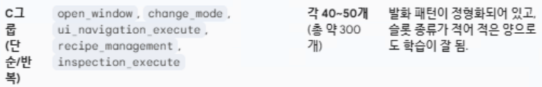   
- set option
- auto_configuration_execute
- set_parameter
---
open window는 자주쓰니까 빼도 될 듯

In [31]:
import random
import json

# -----------------------------
# 1. 슬롯 정의
# -----------------------------

window_names = [
    "lga", "qfn", "bga", "mapping", "strip",
    "history", "light", "calibration", "setting", "lot"
]

# 한국어 표현 매핑
window_korean = {
    "lga": "엘지에이",
    "qfn": "큐에프엔",
    "bga": "비지에이",
    "mapping": "매핑",
    "strip": "스트립",
    "history": "히스토리",
    "light": "조명",
    "calibration": "캘리브레이션",
    "setting": "설정",
    "lot": "랏"
}

templates = [
    "{v} 창 열어",
    "{v} 열어줘",
    "{v} window open",
    "{v} 창 켜",
    "{v} open"
]

# -----------------------------
# 2. 데이터 생성
# -----------------------------

def generate_open_window(total=100):

    dataset = []

    # 최소 1회 보장
    for w in window_names:
        name = random.choice([w, window_korean[w]])
        utterance = random.choice(templates).format(v=name)

        dataset.append({
            "utterance": utterance,
            "intent": "open_window",
            "slots": {
                "window_name": w
            }
        })

    # 나머지 랜덤
    remaining = total - len(window_names)

    for _ in range(remaining):
        w = random.choice(window_names)
        name = random.choice([w, window_korean[w]])
        utterance = random.choice(templates).format(v=name)

        dataset.append({
            "utterance": utterance,
            "intent": "open_window",
            "slots": {
                "window_name": w
            }
        })

    return dataset
# -----------------------------
# 1. 슬롯 정의
# -----------------------------

operations = [
    "RUN",
    "SETUP",
    "PRS_RETEACH",
    "MAPPING_RETEACH"
]

operation_korean = {
    "RUN": "런 모드",
    "SETUP": "셋업 모드",
    "PRS_RETEACH": "PRS 재티칭",
    "MAPPING_RETEACH": "매핑 재티칭"
}

operation_templates = [
    "{v} 실행",
    "{v}로 변경",
    "{v} 모드로 전환",
    "{v} start",
    "{v}"
]

# -----------------------------
# 2. 데이터 생성
# -----------------------------

def generate_change_operation(total=100):

    dataset = []

    # 최소 1회 보장
    for op in operations:
        name = random.choice([op, operation_korean[op]])
        utterance = random.choice(operation_templates).format(v=name)

        dataset.append({
            "utterance": utterance,
            "intent": "change_operation",
            "slots": {
                "operation": op
            }
        })

    # 나머지 랜덤
    remaining = total - len(operations)

    for _ in range(remaining):
        op = random.choice(operations)
        name = random.choice([op, operation_korean[op]])
        utterance = random.choice(operation_templates).format(v=name)

        dataset.append({
            "utterance": utterance,
            "intent": "change_operation",
            "slots": {
                "operation": op
            }
        })

    return dataset

In [32]:
open_data = generate_open_window(110)  # 80개만 학습용으로
change_data = generate_change_operation(110) # 80개만 학습용으로

with open("train_slot_data_sgd_clean.jsonl", "a", encoding="utf-8") as f:
    for item in open_data + change_data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print("open_window + change_operation 200개 생성 완료")

open_window + change_operation 200개 생성 완료


- dont care

In [ ]:
import random
import json

# -----------------------------
# 1. 슬롯 정의
# -----------------------------

window_names = [
    "lga", "qfn", "bga", "mapping", "strip",
    "history", "light", "calibration", "setting", "lot"
]

# 한국어 표현 매핑
window_korean = {
    "lga": "엘지에이",
    "qfn": "큐에프엔",
    "bga": "비지에이",
    "mapping": "매핑",
    "strip": "스트립",
    "history": "히스토리",
    "light": "조명",
    "calibration": "캘리브레이션",
    "setting": "설정",
    "lot": "랏"
}

templates = [
    "{v} 창 열어",
    "{v} 열어줘",
    "{v} window open",
    "{v} 창 켜",
    "{v} open"
]

# -----------------------------
# 2. 데이터 생성
# -----------------------------

def generate_open_window(total=120):

    dataset = []

    none_templates = [
        "창 열어줘",
        "window open",
        "화면 켜"
    ]

    while len(dataset) < total:

        r = random.random()

        # =========================
        # 1️⃣ FULL (70%)
        # =========================
        if r < 0.7:

            w = random.choice(window_names)
            spoken = random.choice([w, window_korean[w]])
            utterance = random.choice(templates).format(v=spoken)

            slots = {
                "window_name": {
                    "value": w,
                    "status": "ACTIVE"
                }
            }

        # =========================
        # 2️⃣ TYPE ONLY (20%)
        # ========================= ㅓ왜 있는갸ㅕ
        # elif r < 0.9:

        #     w = random.choice(window_names)
        #     spoken = random.choice([w, window_korean[w]])
        #     utterance = spoken

        #     slots = {
        #         "window_name": {
        #             "value": w,
        #             "status": "ACTIVE"
        #         }
        #     }

        # =========================
        # 3️⃣ NONE (10%)
        # =========================
        else:

            utterance = random.choice(none_templates)
            slots = {
                "window_name": {
                    "value": None,
                    "status": "NONE"
                }
            }

        dataset.append({
            "utterance": utterance,
            "intent": "open_window",
            "slots": slots
        })

    return dataset
# -----------------------------
# 1. 슬롯 정의
# -----------------------------

operations = [
    "RUN",
    "SETUP",
    "PRS_RETEACH",
    "MAPPING_RETEACH"
]

operation_korean = {
    "RUN": ["RUN", "런", "런 모드"],
    "SETUP": ["SETUP", "셋업", "셋업 모드"],
    "PRS_RETEACH": ["PRS_RETEACH", "PRS 재티칭", "피알에스 재티칭"],
    "MAPPING_RETEACH": ["MAPPING_RETEACH", "매핑 재티칭"]
}

operation_templates = [
    "{v} 실행",
    "{v}로 변경",
    "{v} 모드로 전환",
    "{v} start",
    "{v}"
]

# -----------------------------
# 2. 데이터 생성
# -----------------------------
def generate_change_operation(total=120):

    dataset = []

    none_templates = [
        "모드 변경",
        "operation 바꿔",
        "동작 전환"
    ]

    while len(dataset) < total:

        r = random.random()

        # =========================
        # 1️⃣ FULL (70%)
        # =========================
        if r < 0.7:

            op = random.choice(operations)
            spoken = random.choice(operation_korean[op])
            utterance = random.choice(operation_templates).format(v=spoken)

            slots = {
                "operation": {
                    "value": op,
                    "status": "ACTIVE"
                }
            }

        # =========================
        # 2️⃣ TYPE ONLY (20%)
        # =========================
        elif r < 0.9:

            op = random.choice(operations)
            spoken = random.choice(operation_korean[op])
            utterance = spoken

            slots = {
                "operation": {
                    "value": op,
                    "status": "ACTIVE"
                }
            }

        # =========================
        # 3️⃣ NONE (10%)
        # =========================
        else:

            utterance = random.choice(none_templates)

            slots = {
                "operation": {
                    "value": None,
                    "status": "NONE"
                }
            }

        dataset.append({
            "utterance": utterance,
            "intent": "change_operation",
            "slots": slots
        })

    return dataset


open_data = generate_open_window(100)  # 80개만 학습용으로
change_data = generate_change_operation(100) # 80개만 학습용으로

with open("[status]slotData.jsonl", "a", encoding="utf-8") as f:
    for item in open_data + change_data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print("open_window + change_operation 200개 생성 완료")


open_window + change_operation 200개 생성 완료


- inspection execute (120)

In [ ]:
import random
import json
import re

# -----------------------------
# 1. 슬롯 정의
# -----------------------------

inspection_map = {
    "lga": [
        "FindPackagesTeaching",
        "findpadsTeaching",
        "findLeadsTeaching",
        "findSurfaceTeaching",
        "findSawingTeaching",
        "inspectRejectMarkTeaching",
        "inspectTeaching"
    ],
    "qfn": [
        "inspectPackageTeaching",
        "inspectPadAndLeadsTeaching",
        "inspectSurfaceTeaching",
        "inspectSawingTeaching",
        "inspectRejectMarkTeaching",
        "inspectTeaching"
    ],
    "bga": [
        "inspectPackageTeaching",
        "findFirstPinAndPatternTeaching",
        "findBallsTeaching",
        "inspectSurfaceTeaching",
        "inspectSawingTeaching",
        "inspectRejectMarkTeaching",
        "inspectTeaching"
    ],
    "mapping": [
        "findPackagesTeaching",
        "inspectMarksAndDataCodeTeaching",
        "inspectSurfaceTeaching",
        "inspectSawingTeaching",
        "inspectRejectMarkTeaching",
        "inspectTeaching"
    ]
}

window_korean = {
    "lga": "엘지에이",
    "qfn": "큐에프엔",
    "bga": "비지에이",
    "mapping": "매핑"
}
def camel_to_korean_pron(text):
    words = re.findall(r'[A-Z]?[a-z]+|[A-Z]+(?=[A-Z]|$)', text)

    mapping = {
        "Find": "파인드",
        "Packages": "패키지",
        "Package": "패키지",
        "Pads": "패드",
        "Pad": "패드",
        "Leads": "리드",
        "Lead": "리드",
        "Surface": "서피스",
        "Sawing": "소잉",
        "Reject": "리젝트",
        "Mark": "마크",
        "Marks": "마크",
        "Data": "데이터",
        "Code": "코드",
        "Balls": "볼",
        "Ball": "볼",
        "First": "퍼스트",
        "Pin": "핀",
        "Pattern": "패턴",
        "Inspect": "인스펙트",
        "Teaching": "티칭",
        "And": "앤드"
    }

    converted = []
    for w in words:
        converted.append(mapping.get(w, w))

    return " ".join(converted)
# -----------------------------
# 2. camel → 자연어 변환
# -----------------------------

def camel_to_text(text):
    words = re.findall(r'[A-Z]?[a-z]+|[A-Z]+(?=[A-Z]|$)', text)
    return " ".join(words).lower()

# -----------------------------
# 3. 템플릿
# -----------------------------

templates = [
    "{w}에서 {t} 실행",
    "{w} {t} 검사해",
    "{t} 실행해줘",
    "{w} 창 {t} 테스트",
    "{t} teaching start"
]

# -----------------------------
# 4. 데이터 생성
# -----------------------------

def generate_inspection_execute(total=120):

    dataset = []

    # 1️⃣ 모든 조합 최소 1회 보장
    for window, types in inspection_map.items():
        for t in types:

            natural = camel_to_text(t)
            w_name = random.choice([window, window_korean[window]])
            korean_pron = camel_to_korean_pron(t)

            utterance = random.choice(templates).format(
                w=w_name,
                t=random.choice([t, natural, korean_pron])
            )

            dataset.append({
                "utterance": utterance,
                "intent": "inspection_execute",
                "slots": {
                    "window_name": window,
                    "inspection_type": t
                }
            })

    # 2️⃣ 남은 개수 랜덤
    remaining = total - len(dataset)

    windows = list(inspection_map.keys())

    for _ in range(max(0, remaining)):

        window = random.choice(windows)
        t = random.choice(inspection_map[window])

        natural = camel_to_text(t)
        w_name = random.choice([window, window_korean[window]])

        utterance = random.choice(templates).format(
            w=w_name,
            t=random.choice([t, natural])
        )

        dataset.append({
            "utterance": utterance,
            "intent": "inspection_execute",
            "slots": {
                "window_name": window,
                "inspection_type": t
            }
        })

    return dataset

In [40]:
data = generate_inspection_execute(150)

with open("train_slot_data_sgd_clean.jsonl", "a", encoding="utf-8") as f:
    for item in data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print("inspection_execute 120개 생성 완료:", len(data))

inspection_execute 120개 생성 완료: 150


- dont care

In [ ]:
import random
import json
import re

# -----------------------------
# 1. 슬롯 정의
# -----------------------------

inspection_map = {
    "lga": [
        "findPackagesTeaching",
        "findpadsTeaching",
        "findLeadsTeaching",
        "findSurfaceTeaching",
        "findSawingTeaching",
        "inspectRejectMarkTeaching",
        "inspectTeaching"
    ],
    "qfn": [
        "inspectPackageTeaching",
        "inspectPadAndLeadsTeaching",
        "inspectSurfaceTeaching",
        "inspectSawingTeaching",
        "inspectRejectMarkTeaching",
        "inspectTeaching"
    ],
    "bga": [
        "inspectPackageTeaching",
        "findFirstPinAndPatternTeaching",
        "findBallsTeaching",
        "inspectSurfaceTeaching",
        "inspectSawingTeaching",
        "inspectRejectMarkTeaching",
        "inspectTeaching"
    ],
    "mapping": [
        "findPackagesTeaching",
        "inspectMarksAndDataCodeTeaching",
        "inspectSurfaceTeaching",
        "inspectSawingTeaching",
        "inspectRejectMarkTeaching",
        "inspectTeaching"
    ]
}

window_korean = {
    "lga": "엘지에이",
    "qfn": "큐에프엔",
    "bga": "비지에이",
    "mapping": "매핑"
}

# -----------------------------
# 2. CamelCase → 한국어 발음 변환
# -----------------------------
mapping = {
    "Find": ["파인드", "찾기"],
    "Packages": ["패키지"],
    "Package": ["패키지"],
    "Pads": ["패드"],
    "Pad": ["패드"],
    "Leads": ["리드"],
    "Lead": ["리드"],
    "Surface": ["서피스"],
    "Sawing": ["소잉"],
    "Reject": ["리젝트"],
    "Mark": ["마크"],
    "Marks": ["마크"],
    "Data": ["데이터","데이타"],
    "Code": ["코드"],
    "Balls": ["볼"],
    "Ball": ["볼"],
    "First": ["퍼스트"],
    "Pin": ["핀"],
    "Pattern": ["패턴"],
    "Inspect": ["인스펙트"],
    "Teaching": ["티칭"],
    "And": ["앤드"]
}

def camel_to_text(text):
    words = re.findall(r'[A-Z]?[a-z]+|[A-Z]+(?=[A-Z]|$)', text)
    return " ".join(words).lower()

def camel_to_korean_pron(text):
    words = re.findall(r'[A-Z]?[a-z]+|[A-Z]+(?=[A-Z]|$)', text)
    converted = [random.choice(mapping[w]) if w in mapping else w for w in words]
    return " ".join(converted)
# -----------------------------
# 4. 템플릿
# -----------------------------
templates = [
    "{w}에서 {t} 실행",
    "{w} {t} 검사해",
    "{t} 실행해줘",
    "{w} 창 {t} 테스트",
    "{t} teaching start"
]

type_only_templates = [
        "{t} 실행해줘",
        "{t} teaching start"
]

# -----------------------------
# 5. 데이터 생성
# -----------------------------
# 코드 읽기 시작
def generate_inspection_execute(total=120):
    dataset = []
    none_templates = [
        "검사 실행",
        "티칭 테스트",
        "테스트 시작",
        "창 검사해"
    ]
    windows = list(inspection_map.keys())

    while len(dataset) < total:
        r = random.random()

        if r < 0.7:  # FULL
            window = random.choice(windows)
            t = random.choice(inspection_map[window])

            # 창 이름은 반드시 포함
            w_name = random.choice([window, window_korean[window]])
            
            # 검사 타입은 자연어 또는 한글 발음만
            t_text = random.choice([camel_to_text(t), camel_to_korean_pron(t)])
            
            # FULL 전용 템플릿 사용 (window_name 포함)
            template = random.choice([
                "{w}에서 {t} 실행",
                "{w} {t} 검사해",
                "{w} 창 {t} 테스트"
            ])
            
            # 창 이름과 검사 타입을 반드시 포함
            utterance = template.format(w=w_name, t=t_text)
            
            slots = {
                "window_name": {"value": window, "status": "ACTIVE"},
                "inspection_type": {"value": t, "status": "ACTIVE"}
            }

        elif r < 0.9:  # TYPE ONLY
            window = random.choice(windows)
            t = random.choice(inspection_map[window])
            t_text = random.choice([t, camel_to_text(t), camel_to_korean_pron(t)])
            template = random.choice(type_only_templates)
            utterance = template.format(t=t_text)
            utterance = t_text
            slots = {
                "window_name": {"value": None, "status": "NONE"},
                "inspection_type": {"value": t, "status": "ACTIVE"}
            }

        else:  # NONE
            utterance = random.choice(none_templates)
            slots = {
                "window_name": {"value": None, "status": "NONE"},
                "inspection_type": {"value": None, "status": "NONE"}
            }

        dataset.append({
            "utterance": utterance,
            "intent": "inspection_execute",
            "slots": slots
        })

    return dataset

# -----------------------------
# 6. JSONL 파일 저장 예시
# -----------------------------
inspection_data = generate_inspection_execute(120)
with open("[status]slotData.jsonl", "a", encoding="utf-8") as f:
    for item in inspection_data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print("inspection_execute 120개 생성 완료")

inspection_execute 120개 생성 완료


- set_option + auto_configuration_execute

In [ ]:
import random
import json
import re

def find_span(text, value):
    start = text.find(value)
    if start == -1:
        return None, None
    return start, start + len(value)

def camel_to_text(text):
    words = re.findall(r'[A-Z]?[a-z]+|[A-Z]+(?=[A-Z]|$)', text)
    return " ".join(words).lower()

def camel_to_korean_pron(text):
    words = re.findall(r'[A-Z]?[a-z]+|[A-Z]+(?=[A-Z]|$)', text)

    mapping = {
        "Edge": "엣지",
        "Detect": "디텍트",
        "Direction": "디렉션",
        "Mode": "모드",
        "First": "퍼스트",
        "Pin": "핀",
        "Type": "타입",
        "Rotate": "로테이트",
        "Angle": "앵글",
        "In": "인",
        "Out": "아웃",
        "Black": "블랙",
        "White": "화이트",
        "Small": "스몰",
        "Pad": "패드",
        "Notch": "노치",
        "Chamfer": "챔퍼",
        "Auto": "오토",
        "Roi": "로이",
        "Generate": "제너레이트",
        "Threshold": "쓰레숄드",
        "Set": "셋",
        "Find": "파인드",
        "Ball": "볼",
        "Command": "커맨드"
    }

    return " ".join([mapping.get(w, w) for w in words])

In [ ]:
def generate_set_option(total=150):

    dataset = []

    window_map = {
        "lga": ["EdgeDetectDirection","EdgeDetectMode","FirstPinType"],
        "qfn": ["EdgeDetectDirection","EdgeDetectMode","FirstPinType"],
        "bga": ["EdgeDetectDirection","EdgeDetectMode"],
        "mapping": ["EdgeDetectDirection","EdgeDetectMode","RotateAngle"]
    }

    value_map = {
        "EdgeDetectDirection": ["InToOut","OutToIn"],
        "EdgeDetectMode": ["BlackToWhite","WhiteToBlack"],
        "RotateAngle": ["0","90","180","270"],
        "FirstPinType": ["SmallPad","Notch","Chamfer"]
    }

    templates = [
        "{w} {t} {v}로 설정",
        "{w}에서 {t} {v}로 변경",
        "{t}를 {v}로"
    ]

    # 최소 1회 보장
    for w, types in window_map.items():
        for t in types:
            v = random.choice(value_map[t])

            t_expr = random.choice([t, camel_to_text(t), camel_to_korean_pron(t)])
            v_expr = random.choice([v, camel_to_text(v), camel_to_korean_pron(v)])

            utterance = random.choice(templates).format(w=w, t=t_expr, v=v_expr)

            start, end = find_span(utterance, v_expr)

            dataset.append({
                "utterance": utterance,
                "intent": "set_option",
                "slots": {
                    "window_name": w,
                    "option_type": t,
                    "option_value": v
                }
            })

    # 나머지 랜덤
    while len(dataset) < total:

        w = random.choice(list(window_map.keys()))
        t = random.choice(window_map[w])
        v = random.choice(value_map[t])

        t_expr = random.choice([t, camel_to_text(t), camel_to_korean_pron(t)])
        v_expr = random.choice([v, camel_to_text(v), camel_to_korean_pron(v)])

        utterance = random.choice(templates).format(w=w, t=t_expr, v=v_expr)

        dataset.append({
            "utterance": utterance,
            "intent": "set_option",
            "slots": {
                "window_name": w,
                "option_type": t,
                "option_value": v
            }
        })

    return dataset
def generate_auto_config(total=150):

    dataset = []

    windows = ["lga","qfn","bga","mapping"]
    auto_types = ["AutoRoiGenerate","AutoThresholdSet","findBallRoiAutoCommand"]

    templates = [
        "{w} {t} 실행",
        "{w}에서 {t} 시작"
    ]

    # 최소 1회 보장
    for w in windows:
        for t in auto_types:

            t_expr = random.choice([t, camel_to_text(t), camel_to_korean_pron(t)])

            utterance = random.choice(templates).format(w=w, t=t_expr)

            dataset.append({
                "utterance": utterance,
                "intent": "auto_configuration_execute",
                "slots": {
                    "window_name": w,
                    "auto_type": t
                }
            })

    # 랜덤 채우기
    while len(dataset) < total:

        w = random.choice(windows)
        t = random.choice(auto_types)

        t_expr = random.choice([t, camel_to_text(t), camel_to_korean_pron(t)])

        utterance = random.choice(templates).format(w=w, t=t_expr)

        dataset.append({
            "utterance": utterance,
            "intent": "auto_configuration_execute",
            "slots": {
                "window_name": w,
                "auto_type": t
            }
        })

    return dataset
    

In [ ]:
data1 = generate_set_option(150)
data2 = generate_auto_config(150)

all_data = data1 + data2

with open("train_slot_data_sgd_clean.jsonl", "a", encoding="utf-8") as f:
    for item in all_data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print("set_option + auto_configuration_execute 생성 완료:", len(all_data))

- dont care
- 이거 잘못 된 것. 라벨링잘못됨

In [7]:
import random
import json
import re

def find_span(text, value):
    start = text.find(value)
    if start == -1:
        return None, None
    return start, start + len(value)


def camel_to_text(text):
    words = re.findall(r'[A-Z]?[a-z]+|[A-Z]+(?=[A-Z]|$)', text)
    return " ".join(words).lower()


def camel_to_korean_pron(text):
    words = re.findall(r'[A-Z]?[a-z]+|[A-Z]+(?=[A-Z]|$)', text)

    mapping = {
        "Edge": ["엣지"],
        "Detect": ["디텍트", "감지"],
        "Direction": ["디렉션", "방향"],
        "Mode": ["모드"],
        "First": ["퍼스트","첫"],
        "Pin": ["핀"],
        "Type": ["타입"],
        "Rotate": ["로테이트","회전"],
        "Angle": ["앵글","각도"],
        "In": ["인", "안", "내부"],
        "Out": ["아웃", "밖", "외부"],
        "To": ["에서"],
        "Black": ["블랙", "검정", "흑"],
        "White": ["화이트", "흰색", "백"],
        "BlackToWhite": ["블랙에서 화이트로","흑에서 백으로","검정에서 흰색으로", "흑백"],
        "WhiteToBlack": ["화이트에서 블랙으로","백에서 흑으로", "흰색에서 검정색으로","백흑"],
        "Small": ["스몰"],
        "Pad": ["패드"],
        "Notch": ["노치"],
        "Chamfer": ["챔퍼"],
        "Auto": ["오토","자동"],
        "Roi": ["로이"],
        "Generate": ["생성", ""],
        "Threshold": ["쓰레숄드", "임계값"],
        "Set": ["셋"],
        "Find": ["파인드"],
        "Ball": ["볼"],
        "Command": ["커맨드"]
    }

    # 단어별로 리스트에서 랜덤 선택
    converted = [random.choice(mapping[w]) if w in mapping else w for w in words]
    return " ".join(converted)

def generate_set_option(total=150):
    dataset = []

    window_map = {
        "lga": ["EdgeDetectDirection","EdgeDetectMode","FirstPinType"],
        "qfn": ["EdgeDetectDirection","EdgeDetectMode","FirstPinType"],
        "bga": ["EdgeDetectDirection","EdgeDetectMode"],
        "mapping": ["EdgeDetectDirection","EdgeDetectMode","RotateAngle"]
    }

    value_map = {
        "EdgeDetectDirection": ["InToOut","OutToIn"],
        "EdgeDetectMode": ["BlackToWhite","WhiteToBlack"],
        "RotateAngle": ["0","90","180","270"],
        "FirstPinType": ["SmallPad","Notch","Chamfer"]
    }

    full_templates = [
        "{w} {t} {v} 설정",
        "{w}에서 {t} {v} 변경",
        "{w} {t}를 {v}로 설정"
    ]

    type_and_value = [
        "{t} {v} 설정",
        "{t} {v} 변경",
        "{t}를 {v}로 설정"
    ]

    type_only_templates = [
        "{t} 설정",
        "{t} 변경",
        "{t} 바꿔"
    ]

    value_only_templates = [
        "{v}로 설정",
        "{v}로 변경",
        "{v}"
    ]

    none_templates = [
        "옵션 설정",
        "설정 변경",
        "값 바꿔"
    ]

    windows = list(window_map.keys())

    while len(dataset) < total:
        r = random.random()

        if r < 0.6:  # FULL
            w = random.choice(windows)
            t = random.choice(window_map[w])
            v = random.choice(value_map[t])
            t_expr = random.choice([t, camel_to_text(t), camel_to_korean_pron(t)])
            v_expr = random.choice([v, camel_to_text(v), camel_to_korean_pron(v)])
            utterance = random.choice(full_templates).format(w=w, t=t_expr, v=v_expr)
            slots = {
                "window_name": {"value": w, "status": "ACTIVE"},
                "option_type": {"value": t, "status": "ACTIVE"},
                "option_value": {"value": v, "status": "ACTIVE"}
            }

        elif r < 0.7:  # TYPE ONLY
            w = random.choice(windows)
            t = random.choice(window_map[w])
            v = random.choice(value_map[t])
            t_expr = random.choice([t, camel_to_text(t), camel_to_korean_pron(t)])
            utterance = random.choice(type_only_templates).format(t=t_expr)
            slots = {
                "window_name": {"value": None, "status": "NONE"},
                "option_type": {"value": t, "status": "ACTIVE"},
                "option_value": {"value": None, "status": "NONE"}
            }
        elif r < 0.8:  # TYPE ONLY+ value only
            w = random.choice(windows)
            t = random.choice(window_map[w])
            v = random.choice(value_map[t])
            t_expr = random.choice([t, camel_to_text(t), camel_to_korean_pron(t)])
            utterance = random.choice(type_and_value).format(t=t_expr, v=v_expr)
            slots = {
                "window_name": {"value": None, "status": "NONE"},
                "option_type": {"value": t, "status": "ACTIVE"},
                "option_value": {"value": v, "status": "ACTIVE"}
            }

        # ---------------- VALUE ONLY ----------------
        elif r < 0.9:
            # 타입 먼저 선택
            t = random.choice(list(value_map.keys()))
            v = random.choice(value_map[t])

            v_expr = random.choice([camel_to_text(v), camel_to_korean_pron(v)])

            utterance = random.choice(value_only_templates).format(t=t_expr, v=v_expr)

            slots = {
                "window_name": {"value": None, "status": "NONE"},
                "option_type": {"value": None, "status": "NONE"},
                "option_value": {"value": v, "status": "ACTIVE"}
            }
        else:  # NONE
            utterance = random.choice(none_templates)
            slots = {
                "window_name": {"value": None, "status": "NONE"},
                "option_type": {"value": None, "status": "NONE"},
                "option_value": {"value": None, "status": "NONE"}
            }

        dataset.append({
            "utterance": utterance,
            "intent": "set_option",
            "slots": slots
        })

    return dataset

# -----------------------------
# auto_configuration_execute도 동일 구조
# -----------------------------

def generate_auto_config(total=150):
    dataset = []
    
    auto_type_map = {
        "lga": ["AutoRoiGenerate", "AutoThresholdSet"],
        "qfn": ["AutoRoiGenerate", "AutoThresholdSet"],
        "mapping": ["AutoRoiGenerate", "AutoThresholdSet"],
        "bga": ["AutoRoiGenerate", "AutoThresholdSet", "findBallRoiAutoCommand"]
    }
    windows = list(auto_type_map.keys())

    templates = [
        "{w} {t} 실행",
        "{w}에서 {t} 시작"
    ]

    none_templates = [
        "자동 실행",
        "자동 설정 시작"
    ]

    while len(dataset) < total:
        r = random.random()

        if r < 0.7:  # FULL
            w = random.choice(windows) # windows
            t = random.choice(auto_type_map[w])
            t_expr = random.choice([t, camel_to_text(t), camel_to_korean_pron(t)])
            utterance = random.choice(templates).format(w=w, t=t_expr)
            slots = {
                "window_name": {"value": w, "status": "ACTIVE"},
                "auto_type": {"value": t, "status": "ACTIVE"}
            }

        elif r < 0.9:  # TYPE ONLY
            window = random.choice(windows)
            t = random.choice(auto_type_map[window])
            t_expr = random.choice([t, camel_to_text(t), camel_to_korean_pron(t)])
            utterance = t_expr
            slots = {
                "window_name": {"value": None, "status": "NONE"},
                "auto_type": {"value": t, "status": "ACTIVE"}
            }

        else:  # NONE
            utterance = random.choice(none_templates)
            slots = {
                "window_name": {"value": None, "status": "NONE"},
                "auto_type": {"value": None, "status": "NONE"}
            }

        dataset.append({
            "utterance": utterance,
            "intent": "auto_configuration_execute",
            "slots": slots
        })

    return dataset

data1 = generate_set_option(150)
data2 = generate_auto_config(150)
all_data = data1 + data2
with open("[status]slotData.jsonl", "a", encoding="utf-8") as f:
    for item in all_data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print("set_option + auto_configuration_execute 생성 완료:", len(all_data))

set_option + auto_configuration_execute 생성 완료: 300


- 0226 목
- set option 수정

In [107]:
import json

input_path = r"[status]data_complete1.jsonl"
output_path = r"[status]data_complete2.jsonl"

with open(input_path, "r", encoding="utf-8") as fin, \
     open(output_path, "w", encoding="utf-8") as fout:
    
    for line in fin:
        item = json.loads(line.strip())
        
        # set_option 인텐트는 제외
        if item.get("intent") == "set_option":
            continue
        
        fout.write(json.dumps(item, ensure_ascii=False) + "\n")

print("set_option 제거 완료:", output_path)

set_option 제거 완료: [status]data_complete2.jsonl


In [108]:
import random
import json

output_path = r"[status]data_complete2.jsonl"

# ── 매핑 ───────────────────────────────────────────────────────────────────────
window_map = {
    "lga":     ["EdgeDetectDirection", "EdgeDetectMode", "FirstPinType"],
    "qfn":     ["EdgeDetectDirection", "EdgeDetectMode", "FirstPinType"],
    "bga":     ["EdgeDetectDirection", "EdgeDetectMode"],
    "mapping": ["EdgeDetectDirection", "EdgeDetectMode", "RotateAngle"],
}

value_map = {
    "EdgeDetectDirection": ["InToOut", "OutToIn"],
    "EdgeDetectMode":      ["BlackToWhite", "WhiteToBlack"],
    "RotateAngle":         ["0", "90", "180", "270"],
    "FirstPinType":        ["SmallPad", "Notch", "Chamfer"],
}

# option_type 표현 변형 (발화용)
type_expr = {
    "EdgeDetectDirection": ["EdgeDetectDirection", "엣지 디텍트 디렉션", "에지 감지 방향"],
    "EdgeDetectMode":      ["EdgeDetectMode", "엣지 디텍트 모드", "에지 감지 모드"],
    "FirstPinType":        ["FirstPinType", "퍼스트 핀 타입", "첫 번째 핀 종류"],
    "RotateAngle":         ["RotateAngle", "로테이트 앵글", "회전 각도"],
}

# option_value 표현 변형 (발화용) — 정답값과 1:1 매핑
value_expr = {
    "InToOut":       ["InToOut", "내부에서 외부", "인 투 아웃"],
    "OutToIn":       ["OutToIn", "외부에서 내부", "아웃 투 인"],
    "BlackToWhite":  ["BlackToWhite", "흑에서 백", "블랙 투 화이트"],
    "WhiteToBlack":  ["WhiteToBlack", "백에서 흑", "화이트 투 블랙"],
    "0":             ["0", "0도"],
    "90":            ["90", "90도"],
    "180":           ["180", "180도"],
    "270":           ["270", "270도"],
    "SmallPad":      ["SmallPad", "스몰 패드", "작은 패드"],
    "Notch":         ["Notch", "노치"],
    "Chamfer":       ["Chamfer", "챔퍼"],
}

# 발화 템플릿
full_templates  = ["{w} {t} {v}로 설정", "{w}에서 {t}를 {v}로 변경", "{w} {t} {v}"]
wt_templates    = ["{w} {t} 설정", "{w}에서 {t} 변경"]
tv_templates    = ["{t}를 {v}로 설정", "{t} {v}로 변경"]
v_templates = ["{v}로 설정", "{v} 적용", "{v} 변경"]
none_templates  = ["옵션 설정", "설정 변경해줘"]


def none_slot():
    return {"value": None, "status": "NONE"}


def generate_set_option(total=250):
    dataset = []

    # 최소 1회 보장 (full: window + type + value)
    for w, types in window_map.items():
        for t in types:
            v = random.choice(value_map[t])
            t_e = random.choice(type_expr[t])
            v_e = random.choice(value_expr[v])
            utterance = random.choice(full_templates).format(w=w, t=t_e, v=v_e)
            dataset.append({
                "utterance": utterance,
                "intent": "set_option",
                "slots": {
                    "window_name": {"value": w, "status": "ACTIVE"},
                    "option_type":  {"value": t, "status": "ACTIVE"},
                    "option_value": {"value": v, "status": "ACTIVE"},
                }
            })

    # 나머지 랜덤 (4가지 케이스 혼합)
    while len(dataset) < total:
        r = random.random()
        w = random.choice(list(window_map.keys()))
        t = random.choice(window_map[w])
        v = random.choice(value_map[t])
        t_e = random.choice(type_expr[t])
        v_e = random.choice(value_expr[v])

        # FULL
        if r < 0.5:
            utterance = random.choice(full_templates).format(w=w, t=t_e, v=v_e)
            slots = {
                "window_name": {"value": w, "status": "ACTIVE"},
                "option_type":  {"value": t, "status": "ACTIVE"},
                "option_value": {"value": v, "status": "ACTIVE"},
            }

        # window + type only
        elif r < 0.7:
            utterance = random.choice(wt_templates).format(w=w, t=t_e)
            slots = {
                "window_name": {"value": w, "status": "ACTIVE"},
                "option_type":  {"value": t, "status": "ACTIVE"},
                "option_value": none_slot(),
            }

        # type + value only (window NONE)
        elif r < 0.85:
            utterance = random.choice(tv_templates).format(t=t_e, v=v_e)
            slots = {
                "window_name": none_slot(),
                "option_type":  {"value": t, "status": "ACTIVE"},
                "option_value": {"value": v, "status": "ACTIVE"},
            }
            # ✅ value ONLY
        elif r < 0.90:
            utterance = random.choice(v_templates).format(v=v_e)
            slots = {
                "window_name": none_slot(),
                "option_type":  none_slot(),
                "option_value": {"value": v, "status": "ACTIVE"},
            }

        # ALL NONE
        else:
            utterance = random.choice(none_templates)
            slots = {
                "window_name": none_slot(),
                "option_type":  none_slot(),
                "option_value": none_slot(),
            }

        dataset.append({"utterance": utterance, "intent": "set_option", "slots": slots})

    return dataset


data = generate_set_option(200)

with open(output_path, "a", encoding="utf-8") as f:
    for item in data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print(f"set_option {len(data)}개 생성 완료 → {output_path}")

set_option 200개 생성 완료 → [status]data_complete2.jsonl


✅ recipe_management
✅ set_parameter

In [10]:
import random
import json
import re

def find_span(text, value):
    start = text.find(value)
    if start == -1:
        return None, None
    return start, start + len(value)

def camel_to_text(text):
    words = re.findall(r'[A-Z]?[a-z]+|[A-Z]+(?=[A-Z]|$)', text)
    return " ".join(words).lower()

def camel_to_korean_pron(text):
    mapping = {
        "Outline": ["아웃라인","외곽선"],
        "Width": ["너비"],
        "Package": ["패키지"],
        "Threshold": ["쓰레숄드", "임계값"],
        "Diff": ["디프", "차이"]
    }
    words = re.findall(r'[A-Z]?[a-z]+|[A-Z]+(?=[A-Z]|$)', text)

    result = []
    for w in words:
        if w in mapping:
            result.append(random.choice(mapping[w]))
        else:
            result.append(w)

    return " ".join(result)

In [62]:
def generate_recipe_management(total=150):

    dataset = []

    actions = ["add","copy","rename","delete","select"]

    action_kor = {
        "add": ["추가","생성"],
        "copy": ["복사"],
        "rename": ["이름변경","이름 변경"],
        "delete": ["삭제"],
        "select": ["선택"]
    }

    recipe_pool = ["RecipeA","RecipeB","Test1","ModelX","Sample"]

    # 최소 1회 보장
    for action in actions:

        recipe_name = random.choice(recipe_pool)
        utterance = ""

        if action in ["add","delete","select"]:
            utterance = f"{recipe_name} 레시피 {random.choice(action_kor[action])}"
            start, end = find_span(utterance, recipe_name)
            dataset.append({
                "utterance": utterance,
                "intent": "recipe_management",
                "slots": {
                    "action": action,
                    "recipe_name": {
                        "value": recipe_name,
                        "start": start,
                        "end": end
                    }
                }
            })

        elif action in ["copy","rename"]:
            target = recipe_name + "_new"

            utterance = f"{recipe_name} 레시피 {random.choice(action_kor[action])} {target}"
            start, end = find_span(utterance, recipe_name)
            t_start, t_end = find_span(utterance, recipe_name)

            dataset.append({
                "utterance": utterance,
                "intent": "recipe_management",
                "slots": {
                    "action": action,
                    "recipe_name": {
                        "value": recipe_name,
                        "start": start,
                        "end": end
                    },
                    "target_name": {
                        "value": target,
                        "start": t_start,
                        "end": t_end
                    }
                }
            })

    # 랜덤 채우기
    while len(dataset) < total:

        action = random.choice(actions)
        recipe_name = random.choice(recipe_pool)

        if action in ["add","delete","select"]:
            utterance = f"{recipe_name} 레시피 {random.choice(action_kor[action])}"
            start, end = find_span(utterance, recipe_name)
            dataset.append({
                "utterance": utterance,
                "intent": "recipe_management",
                "slots": {
                    "action": action,
                    "recipe_name": {
                        "value": recipe_name,
                        "start": start,
                        "end": end
                    }
                }
            })

        else:
            target = recipe_name + "_copy"
            utterance = f"{recipe_name} 레시피 {random.choice(action_kor[action])} {target}"
            start, end = find_span(utterance, recipe_name)
            t_start, t_end = find_span(utterance, recipe_name)
            dataset.append({
                "utterance": utterance,
                "intent": "recipe_management",
                "slots": {
                    "action": action,
                    "recipe_name": {
                        "value": recipe_name,
                        "start": start,
                        "end": end
                    },
                    "target_name": {
                        "value": target,
                        "start": t_start,
                        "end": t_end
                    }
                }
            })

    return dataset
def generate_set_parameter(total=150):

    dataset = []

    windows = ["lga","qfn","bga","mapping"]
    parameters = ["OutlineWidth","PackageThresholdDiff"]

    templates = [
        "{w} {p} {v}로 설정",
        "{w}에서 {p} {v}로 변경",
        "{p} {v}"
    ]

    # 최소 1회 보장
    for w in windows:
        for p in parameters:

            v = str(random.randint(1,300))

            p_expr = random.choice([p, camel_to_text(p), camel_to_korean_pron(p)])

            utterance = random.choice(templates).format(
                w=w,
                p=p_expr,
                v=v
            )

            start, end = find_span(utterance, v)

            dataset.append({
                "utterance": utterance,
                "intent": "set_parameter",
                "slots": {
                    "window_name": w,
                    "parameter_name": p,
                    "value": {
                        "value": v,
                        "start": start,
                        "end": end
                    }
                }
            })

    # 랜덤 채우기
    while len(dataset) < total:

        w = random.choice(windows)
        p = random.choice(parameters)
        v = str(random.randint(1,300))

        p_expr = random.choice([p, camel_to_text(p), camel_to_korean_pron(p)])

        utterance = random.choice(templates).format(
            w=w,
            p=p_expr,
            v=v
        )

        start, end = find_span(utterance, v)

        dataset.append({
            "utterance": utterance,
            "intent": "set_parameter",
            "slots": {
                "window_name": w,
                "parameter_name": p,
                "value": {
                    "value": v,
                    "start": start,
                    "end": end
                }
            }
        })

    return dataset

In [63]:
data1 = generate_recipe_management(150)
data2 = generate_set_parameter(150)

all_data = data1 + data2

with open("train_slot_data_sgd_clean.jsonl", "a", encoding="utf-8") as f:
    for item in all_data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print("recipe_management + set_parameter 생성 완료:", len(all_data))

recipe_management + set_parameter 생성 완료: 300


- dont care

In [18]:
def generate_recipe_management(total=150):

    dataset = []

    actions = ["add", "copy", "rename", "delete", "select"]

    action_kor = {
        "add": ["추가", "생성"],
        "copy": ["복사"],
        "rename": ["이름변경", "이름 변경"],
        "delete": ["삭제"],
        "select": ["선택"]
    }

    recipe_pool = ["RecipeA", "RecipeB", "Test1", "ModelX", "Sample"]

    # ---------------- 최소 1회 보장 ----------------
    for action in actions:

        recipe_name = random.choice(recipe_pool)

        if action in ["add", "delete", "select"]:

            utterance = f"{recipe_name} 레시피 {random.choice(action_kor[action])}"
            start, end = find_span(utterance, recipe_name)

            dataset.append({
                "utterance": utterance,
                "intent": "recipe_management",
                "slots": {
                    "action": {
                        "value": action,
                        "status": "ACTIVE"
                    },
                    "recipe_name": {
                        "value": recipe_name,
                        "start": start,
                        "end": end,
                        "status": "ACTIVE"
                    },
                    "target_name": {
                        "value": None,
                        "start": None,
                        "end": None,
                        "status": "NONE"
                    }
                }
            })

        else:  # copy, rename

            target = recipe_name + "_new"
            utterance = f"{recipe_name} 레시피 {random.choice(action_kor[action])} {target}"

            start, end = find_span(utterance, recipe_name)
            t_start, t_end = find_span(utterance, target)

            dataset.append({
                "utterance": utterance,
                "intent": "recipe_management",
                "slots": {
                    "action": {
                        "value": action,
                        "status": "ACTIVE"
                    },
                    "recipe_name": {
                        "value": recipe_name,
                        "start": start,
                        "end": end,
                        "status": "ACTIVE"
                    },
                    "target_name": {
                        "value": target,
                        "start": t_start,
                        "end": t_end,
                        "status": "ACTIVE"
                    }
                }
            })

    # ---------------- 랜덤 채우기 ----------------
    while len(dataset) < total:

        action = random.choice(actions)
        recipe_name = random.choice(recipe_pool)

        if action in ["add", "delete", "select"]:

            utterance = f"{recipe_name} 레시피 {random.choice(action_kor[action])}"
            start, end = find_span(utterance, recipe_name)

            dataset.append({
                "utterance": utterance,
                "intent": "recipe_management",
                "slots": {
                    "action": {
                        "value": action,
                        "status": "ACTIVE"
                    },
                    "recipe_name": {
                        "value": recipe_name,
                        "start": start,
                        "end": end,
                        "status": "ACTIVE"
                    },
                    "target_name": {
                        "value": None,
                        "start": None,
                        "end": None,
                        "status": "NONE"
                    }
                }
            })

        else:  # copy, rename

            target = recipe_name + "_copy"
            utterance = f"{recipe_name} 레시피 {random.choice(action_kor[action])} {target}"

            start, end = find_span(utterance, recipe_name)
            t_start, t_end = find_span(utterance, target)

            dataset.append({
                "utterance": utterance,
                "intent": "recipe_management",
                "slots": {
                    "action": {
                        "value": action,
                        "status": "ACTIVE"
                    },
                    "recipe_name": {
                        "value": recipe_name,
                        "start": start,
                        "end": end,
                        "status": "ACTIVE"
                    },
                    "target_name": {
                        "value": target,
                        "start": t_start,
                        "end": t_end,
                        "status": "ACTIVE"
                    }
                }
            })

    return dataset

def generate_set_parameter(total=150):

    dataset = []

    windows = ["lga", "qfn", "bga", "mapping"]

    parameter_map = {
        "OutlineWidth",
        "PackageThresholdDiff"
    }

    full_templates = [
        "{w} {p} {v} 설정",
        "{w}에서 {p}를 {v}로 변경",
        "{w} {p} 값 {v}"
    ]

    name_only_templates = [
        "{p} 설정",
        "{p} 변경"
    ]

    value_only_templates = [
        "{v}로 설정",
        "{v}"
    ]

    window_only_templates = [
        "{w}에서 설정",
        "{w} 창 설정"
    ]

    parameter_names = list(parameter_map)

    while len(dataset) < total:

        r = random.random()

        # ---------------- FULL ----------------
        if r < 0.6:
            w = random.choice(windows)
            p = random.choice(parameter_names)
            v = str(random.randint(1, 100))

            p_expr = random.choice([p, camel_to_text(p), camel_to_korean_pron(p)])

            utterance = random.choice(full_templates).format(
                w=w,
                p=p_expr,
                v=v
            )

            slots = {
                "window_name": {"value": w, "status": "ACTIVE"},
                "parameter_name": {"value": p, "status": "ACTIVE"},
                "value": {"value": v, "status": "ACTIVE"}
            }

        # ---------------- NAME ONLY ----------------
        elif r < 0.75:
            p = random.choice(parameter_names)
            p_expr = random.choice([p, camel_to_text(p), camel_to_korean_pron(p)])

            utterance = random.choice(name_only_templates).format(p=p_expr)

            slots = {
                "window_name": {"value": None, "status": "NONE"},
                "parameter_name": {"value": p, "status": "ACTIVE"},
                "value": {"value": None, "status": "NONE"}
            }

        # ---------------- VALUE ONLY ----------------
        elif r < 0.9:
            p = random.choice(parameter_names)
            v = str(random.randint(1, 100))

            utterance = random.choice(value_only_templates).format(v=v)

            slots = {
                "window_name": {"value": None, "status": "NONE"},
                "parameter_name": {"value": None, "status": "NONE"},
                "value": {"value": v, "status": "ACTIVE"}
            }

        # ---------------- WINDOW ONLY ----------------
        else:
            w = random.choice(windows)

            utterance = random.choice(window_only_templates).format(w=w)

            slots = {
                "window_name": {"value": w, "status": "ACTIVE"},
                "parameter_name": {"value": None, "status": "NONE"},
                "value": {"value": None, "status": "NONE"}
            }

        dataset.append({
            "utterance": utterance,
            "intent": "set_parameter",
            "slots": slots
        })

    return dataset

data1 = generate_recipe_management(150)
data2 = generate_set_parameter(150)

all_data = data1 + data2

with open("[status]slotData.jsonl", "a", encoding="utf-8") as f:
    for item in all_data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print("recipe_management + set_parameter 생성 완료:", len(all_data))

recipe_management + set_parameter 생성 완료: 300


---

In [19]:
import json
from collections import Counter

file_path = "[status]slotData.jsonl"

intent_counter = Counter()
total = 0

with open(file_path, "r", encoding="utf-8") as f:
    for i, line in enumerate(f, 1):
        line = line.strip()
        if not line:
            continue
        try:
            data = json.loads(line)
            intent = data.get("intent")
            intent_counter[intent] += 1
            total += 1
        except json.JSONDecodeError:
            print(f"❌ JSON 깨진 줄: {i}")
            print(line[:200])
            break

print("총 개수:", total)

총 개수: 2520


In [111]:
import json
from collections import Counter

file_path = "[status]slotData.jsonl"

intent_counter = Counter()
total = 0

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        data = json.loads(line)
        intent = data.get("intent")
        intent_counter[intent] += 1
        total += 1

print("===== Intent Distribution =====")
for intent, count in intent_counter.items():
    print(f"{intent}: {count}")

print("--------------------------------")
print("Total samples:", total)

===== Intent Distribution =====
set_threshold: 200
set_size: 200
geometry_set: 200
roi_collection_control: 200
open_window: 100
change_operation: 100
inspection_execute: 120
auto_configuration_execute: 150
recipe_management: 150
set_parameter: 150
history_control: 150
calibration_control: 150
set_option: 200
set_boolean: 347
set_number: 301
set_color: 353
--------------------------------
Total samples: 3071


In [74]:
sam1 = {
    "utterance": "bga ContaminationSize 10-50설정", 
    "intent": "set_size", 
    "slots": 
        {
            "window_name": "bga", 
            "size_type": "ContaminationSize", 
            "size_value": 
            {
                "value": "10-50", 
                "start": 22, 
                "end": 27
            }
        }
}

sam2 = {"utterance": "calibration window open", "intent": "open_window", "slots": {"window_name": "calibration"}}
sam3 = {"utterance": "lga에서 패키지 Roi 상단 ROI를 356-163-144-488로 설정", "intent": "geometry_set", "slots": {"window_name": "lga", "geometry_position": "PackageRoiTop_", "coordinate_value": {"value": "356-163-144-488", "start": 22, "end": 37}}}
sam5 = {"utterance": "패키지 임계값 디프 설정", "intent": "set_parameter", "slots": {"window_name": {"value": "null", "status": "NONE"}, "parameter_name": {"value": "PackageThresholdDiff", "status": "ACTIVE"}, "value": {"value": "null", "status": "NONE"}}}
sam4 = {"utterance": "화면 켜", "intent": "open_window", "slots": {"window_name": {"value": "null", "status": "NONE"}}}
sam8 = {"utterance": "모드 변경", "intent": "change_operation", "slots": {"operation": {"value": "null", "status": "NONE"}}}
sam = {"utterance": "MAPPING_RETEACH", "intent": "change_operation", "slots": {"operation": {"value": "MAPPING_RETEACH", "status": "ACTIVE"}}}
utterance = sam["utterance"]
intent = sam["intent"]
slots = sam.get("slots", {})

for slot_name, slot_info in slots.items():
    slot_type = get_slot_type(slot_name, intent)

    print("slot name:", slot_name)

    # 1️⃣ span 구조 (dict)
    if not isinstance(slot_info, dict):
            if slot_info is None:
                status, value, start, end = "NONE", "", -1, -1
                print("type: idk")
            else:
                status = "ACTIVE"
                value = str(slot_info)
                start, end = -1, -1
                print("type: span")
            print("value:", value)
            print("start:", start)
            print("end:", end)


        
    # 2️⃣ categorical / 일반 값
    elif isinstance(slot_info, str):
        status = "ACTIVE"
        value = str(slot_info) if slot_info is not None else ""
        start, end = -1, -1

        print("type: categorical or simple")
        print("value:", value)
    else:
        status = "NONE"
        value, start, end = "", -1, -1
        print("None")
        print("value:", value)

    print()

slot name: operation
None
value: 



In [75]:
samples = []
for slot_name, slot_info in slots.items():
    slot_type = get_slot_type(slot_name, intent)

    # ── 케이스 1: 문자열/숫자 직접 ("operation": "RUN") ─────────────
    if not isinstance(slot_info, dict):
        if slot_info is None:
            status, value, start, end = "NONE", "", -1, -1
        else:
            status = "ACTIVE"
            value = str(slot_info)
            start, end = -1, -1

    # ── 케이스 2 & 3: dict ────────────────────────────────────────────
    else:
        raw_status = slot_info.get("status")   # "ACTIVE" / "NONE" / None
        raw_value  = slot_info.get("value")     # 실제값 / None / "null"

        # "null" 문자열도 None으로 통일
        if raw_value == "null":
            raw_value = None

        # status 명시된 경우 (케이스 3)
        if raw_status is not None:
            # value가 None인데 status가 ACTIVE면 NONE으로 보정
            if raw_value is None:
                status = "NONE"
            else:
                status = raw_status
        # status 없는 경우 (케이스 2) → value 유무로 판단
        else:
            status = "ACTIVE" if raw_value is not None else "NONE"

        if status == "ACTIVE":
            value = str(raw_value)
            start = slot_info.get("start") if slot_info.get("start") is not None else -1
            end   = slot_info.get("end")   if slot_info.get("end")   is not None else -1
        else:
            value, start, end = "", -1, -1
    samples.append({
        "utterance": utterance,
        "intent": intent,
        "slot_name": slot_name,
        "slot_type": slot_type,
        "status": status,
        "value": value,
        "span_start": start,
        "span_end": end,
    })

display(samples)

[{'utterance': 'MAPPING_RETEACH',
  'intent': 'change_operation',
  'slot_name': 'operation',
  'slot_type': 'categorical',
  'status': 'ACTIVE',
  'value': 'MAPPING_RETEACH',
  'span_start': -1,
  'span_end': -1}]

---
- 학습을 시켰으나 속성명을 잘못 설정...

"set_option": ["window_name", "option_type", "option_value"],  
        "set_number": ["window_name", "settingNumPropertyName", "setNumValue"],  
        "set_boolean": ["window_name", "settingBoolPropertyName", "setBoolValue"]  

위와 같이 이름 바꾸기

In [ ]:
# 어차피 바꾸긴 했는데 속성이름도 바꿔야함

import json

# 원본 / 출력 파일
input_file = "[status]slotData.jsonl"
output_file = "slotData_renamed.jsonl"

# intent → 새로운 value 슬롯명 매핑
VALUE_SLOT_MAPPING = {
    "set_color": "setColorValue",
    "set_boolean": "setBoolValue",
    "set_option": "setNumberValue"
}

with open(input_file, "r", encoding="utf-8") as fin, open(output_file, "w", encoding="utf-8") as fout:
    for line in fin:
        sample = json.loads(line.strip())
        intent = sample.get("intent")
        slots = sample.get("slots", {})

        # value 슬롯 이름 바꾸기
        if "value" in slots and intent in VALUE_SLOT_MAPPING:
            new_slot_name = VALUE_SLOT_MAPPING[intent]
            slots[new_slot_name] = slots.pop("value")  # key 교체

        fout.write(json.dumps(sample, ensure_ascii=False) + "\n")

In [ ]:
# parameter vlaue
import json

input_file = "slotData_renamed.jsonl"
output_file = "[status]slotData_renamed2.jsonl"

with open(input_file, 'r', encoding='utf-8') as infile, \
     open(output_file, 'w', encoding='utf-8') as outfile:
    
    for line in infile:
        data = json.loads(line.strip())
        
        if data.get("intent") == "set_parameter":
            slots = data.get("slots", {})
            if "value" in slots:
                # "value" 키 이름을 "parameter_value"로 변경
                slots["parameter_value"] = slots.pop("value")
        
        outfile.write(json.dumps(data, ensure_ascii=False) + "\n")

print(f"변경 완료: {output_file}")

변경 완료: [status]slotData_renamed2.jsonl


In [86]:
import json

input_file = "[status]slotData_renamed2.jsonl"
output_file = "[status]slotData_renamed3.jsonl"

def find_span(utterance, value):
    start = utterance.find(value)
    if start == -1:
        return None, None
    end = start + len(value)
    return start, end

with open(input_file, 'r', encoding='utf-8') as infile, \
     open(output_file, 'w', encoding='utf-8') as outfile:
    
    for line in infile:
        data = json.loads(line.strip())
        
        if data.get("intent") == "set_parameter":
            slots = data.get("slots", {})
            if "value" in slots:
                old_value = slots.pop("value")
                status = old_value.get("status")
                
                # start, end 계산
                if status == "ACTIVE":
                    utterance_text = data.get("utterance", "")
                    start, end = find_span(utterance_text, old_value.get("value"))
                else:
                    start, end = None, None
                
                # 원하는 순서로 새 dict 구성
                new_value_slot = {
                    "value": old_value.get("value"),
                    "start": start,
                    "end": end,
                    "status": status
                }
                
                slots["parameter_value"] = new_value_slot
        
        outfile.write(json.dumps(data, ensure_ascii=False) + "\n")

print(f"변경 완료: {output_file}")

변경 완료: [status]slotData_renamed3.jsonl


In [89]:
import json

# 원본 / 출력 파일
input_file = "[status]slotData_renamed3.jsonl"
output_file = "[status]slotData_renamed4.jsonl"

# intent → 새로운 value 슬롯명 매핑
VALUE_SLOT_MAPPING = {
    "set_color": "setColorValue",
    "set_boolean": "setBoolValue",
    "set_number": "setNumValue"
}

with open(input_file, "r", encoding="utf-8") as fin, open(output_file, "w", encoding="utf-8") as fout:
    for line in fin:
        sample = json.loads(line.strip())
        intent = sample.get("intent")
        slots = sample.get("slots", {})

        # value 슬롯 이름 바꾸기
        if "value" in slots and intent in VALUE_SLOT_MAPPING:
            new_slot_name = VALUE_SLOT_MAPPING[intent]
            slots[new_slot_name] = slots.pop("value")  # key 교체

        # setColorValue, setBoolValue 슬롯이면 start, end 제거
        for key in ["setColorValue", "setBoolValue"]:
            if key in slots:
                slots[key].pop("start", None)
                slots[key].pop("end", None)

        fout.write(json.dumps(sample, ensure_ascii=False) + "\n")

print(f"변경 완료: {output_file}")

변경 완료: [status]slotData_renamed4.jsonl


In [90]:
import json

input_file = "[status]slotData_renamed4.jsonl"
output_file = "[status]slotData_cleaned.jsonl"

with open(input_file, "r", encoding="utf-8") as fin, open(output_file, "w", encoding="utf-8") as fout:
    for line in fin:
        sample = json.loads(line.strip())
        
        # set_color 인텐트인 경우 건너뛰기
        if sample.get("intent") == "set_color":
            continue
        
        fout.write(json.dumps(sample, ensure_ascii=False) + "\n")

print(f"변경 완료: {output_file}")

변경 완료: [status]slotData_cleaned.jsonl


In [97]:
import json
import random

slot_path = r"C:\Users\AMLPC03\deepseers\ragTest\data\slot.json"
output_path = r"[status]slotData_cleaned.jsonl"

with open(slot_path, "r", encoding="utf-8") as f:
    services = json.load(f)

def find_span(text, value):
    start = text.find(value)
    if start == -1:
        return None, None
    return start, start + len(value)

# ── property 수집 ──────────────────────────────────────────────────────────────
number_properties = []
boolean_properties = []
color_properties = []
color_values = []

# intent → property 슬롯 이름 매핑
PROPERTY_SLOT_MAPPING = {
    "set_number":  "settingNumPropertyName",
    "set_boolean": "settingBoolPropertyName",
    "set_color":   "settingColorPropertyName"
}
for service in services:
    if service.get("service_name") != "system_setting":
        continue

    intent_name = service["intents"][0]["name"]
    slots = service.get("slots", [])

    if intent_name == "set_number":
        property_slot = next((s for s in slots if s.get("name") == "settingNumPropertyName"), None)
        if property_slot:
            for window, props in property_slot.get("possible_values_by_window", {}).items():
                number_properties.extend(props)

    elif intent_name == "set_boolean":
        property_slot = next((s for s in slots if s.get("name") == "settingBoolPropertyName"), None)
        if property_slot:
            for window, props in property_slot.get("possible_values_by_window", {}).items():
                boolean_properties.extend(props)

    elif intent_name == "set_color":
        property_slot = next((s for s in slots if "ColorP" in s.get("name", "") or "Colorp" in s.get("name", "")), None)
        if property_slot:
            for window, props in property_slot.get("possible_values_by_window", {}).items():
                color_properties.extend(props)
        value_slot = next((s for s in slots if s.get("name") == "value"), None)
        if value_slot:
            color_values = value_slot.get("possible_values", [])

number_properties  = list(set(number_properties))
boolean_properties = list(set(boolean_properties))
color_properties   = list(set(color_properties))

# ── 템플릿 ─────────────────────────────────────────────────────────────────────
windows = ["lga", "bga", "qfn", "mapping", "recipe", "etc"]

num_full_w  = ["{p}를 {v}로 설정", "{p} {v}로 변경", "{p} 값 {v}"]
num_full    = ["{p}를 {v}로 설정", "{p} {v}로 변경", "{p} 값 {v}"]

bool_full_w = ["{p} 활성화", "{p} 비활성화", "{p} {v} 설정", "{p} {v} 설정"]
bool_full   = ["{p} 활성화", "{p} 비활성화", "{p} {v} 설정", "{p} {v} 설정"]

color_full_w = ["{p}를 {v}로 설정", "{p} {v}로 변경"]
color_full   = ["{p}를 {v}로 설정", "{p} {v}로 변경"]

prop_only = ["{p} 변경", "{p} 설정"]
num_val_only   = ["{v}로 설정", "{v}"]
color_val_only = ["{v}로 변경", "{v}로 설정"]
none_templates = ["설정해줘", "값 바꿔줘", "변경해줘"]

# ── slots 생성 함수 ────────────────────────────────────────────────────────────
def make_window_slots(window=None):
    # window_name 슬롯 제거
    return {}

def generate_data(total=400):
    dataset = []

    while len(dataset) < total:
        r = random.random()

        if r < 0.55:
            intent = random.choice(["set_number", "set_boolean", "set_color"])
            use_window = random.random() < 0.5
            window = random.choice(windows) if use_window else None

            if intent == "set_number":
                p = random.choice(number_properties)
                v = str(random.randint(1, 500))
                if use_window:
                    utterance = random.choice(num_full_w).format(w=window, p=p, v=v)
                else:
                    utterance = random.choice(num_full).format(p=p, v=v)
                start, end = find_span(utterance, v)
                slots = {
                    **make_window_slots(window),
                    "settingNumPropertyName": {"value": p, "status": "ACTIVE"},
                    "settingNumValue":        {"value": v, "start": start, "end": end, "status": "ACTIVE"},
                }

            elif intent == "set_boolean":
                p = random.choice(boolean_properties)
                
                # 활성화/비활성화 결정
                if use_window:
                    template = random.choice(bool_full_w)
                else:
                    template = random.choice(bool_full)
                
                # template에 따라 v 결정
                if "비활성화" in template or "false" in template:
                    v = "false"
                else:
                    v = "true"
                
                # utterance 생성
                if use_window:
                    utterance = template.format(w=window, p=p, v=v)
                else:
                    utterance = template.format(p=p, v=v)
                
                slots = {
                    **make_window_slots(window),
                    "settingBoolPropertyName": {"value": p, "status": "ACTIVE"},
                    "setBoolValue":            {"value": v, "status": "ACTIVE"},
                }

            else:  # set_color
                p = random.choice(color_properties)
                v = random.choice(color_values)
                if use_window:
                    utterance = random.choice(color_full_w).format(w=window, p=p, v=v)
                else:
                    utterance = random.choice(color_full).format(p=p, v=v)
                slots = {
                    **make_window_slots(window),
                    "settingColorPropertyName": {"value": p, "status": "ACTIVE"},
                    "setColorValue":            {"value": v, "status": "ACTIVE"},
                }

        elif r < 0.75:
            intent = random.choice(["set_number", "set_boolean", "set_color"])
            p_key, v_key, v_type = {
                "set_number":  ("settingNumPropertyName",   "settingNumValue",   "span"),
                "set_boolean": ("settingBoolPropertyName",  "setBoolValue",      "categorical"),
                "set_color":   ("settingColorPropertyName", "setColorValue",     "categorical"),
            }[intent]
            props = {"set_number": number_properties,
                     "set_boolean": boolean_properties,
                     "set_color": color_properties}[intent]
            p = random.choice(props)
            utterance = random.choice(prop_only).format(p=p)
            none_val = {"value": None, "status": "NONE"}
            slots = {
                **make_window_slots(None),
                p_key: {"value": p, "status": "ACTIVE"},
                v_key: none_val,
            }

        elif r < 0.9:
            intent = random.choice(["set_number", "set_color"])

            if intent == "set_number":
                v = str(random.randint(1, 500))
                utterance = random.choice(num_val_only).format(v=v)
                start, end = find_span(utterance, v)
                slots = {
                    **make_window_slots(None),
                    "settingNumPropertyName": {"value": None, "status": "NONE"},
                    "settingNumValue":        {"value": v, "start": start, "end": end, "status": "ACTIVE"},
                }
            else:
                v = random.choice(color_values)
                utterance = random.choice(color_val_only).format(v=v)
                slots = {
                    **make_window_slots(None),
                    "settingColorPropertyName": {"value": None, "status": "NONE"},
                    "setColorValue":            {"value": v, "status": "ACTIVE"},
                }

        else:
            intent = random.choice(["set_number", "set_boolean", "set_color"])
            utterance = random.choice(none_templates)
            p_key, v_key = {
                "set_number":  ("settingNumPropertyName",   "settingNumValue"),
                "set_boolean": ("settingBoolPropertyName",  "setBoolValue"),
                "set_color":   ("settingColorPropertyName", "setColorValue"),
            }[intent]
            slots = {
                **make_window_slots(None),
                p_key: {"value": None, "status": "NONE"},
                v_key: {"value": None, "status": "NONE"},
            }

        dataset.append({"utterance": utterance, "intent": intent, "slots": slots})

    return dataset

data = generate_data(400)

with open(output_path, "a", encoding="utf-8") as f:
    for item in data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print("system_setting 데이터 생성 완료:", len(data))

system_setting 데이터 생성 완료: 400


---
위는 각 속성마다 랜덤하게 나옴  
아래는 각 속성마다 적어도 3번 보장

In [109]:
# [status]data_complete2.jsonl 에서 intent가 set_number, set_boolean, set_color
# 인거 지워버리기. [status]no_setting.jsonl 으러ㅗ 저장

import json

input_path = r"[status]data_complete2.jsonl"
output_path = r"[status]no_setting.jsonl"

remove_intents = {"set_number", "set_boolean", "set_color"}

removed_count = 0
kept_count = 0

with open(input_path, "r", encoding="utf-8") as fin, \
     open(output_path, "w", encoding="utf-8") as fout:
    
    for line in fin:
        item = json.loads(line.strip())
        
        if item.get("intent") in remove_intents:
            removed_count += 1
            continue
        
        fout.write(json.dumps(item, ensure_ascii=False) + "\n")
        kept_count += 1

print("삭제된 개수:", removed_count)
print("남은 개수:", kept_count)
print("저장 완료 →", output_path)

삭제된 개수: 400
남은 개수: 2070
저장 완료 → [status]no_setting.jsonl


In [110]:
import json
import random

slot_path = r"C:\Users\AMLPC03\deepseers\ragTest\data\slot.json"
output_path = r"[status]no_setting.jsonl"

with open(slot_path, "r", encoding="utf-8") as f:
    services = json.load(f)

def find_span(text, value):
    start = text.find(value)
    if start == -1:
        return None, None
    return start, start + len(value)

# ── property 수집 ──────────────────────────────────────────────────────────────
number_properties  = []
boolean_properties = []
color_properties   = []
color_values       = []

for service in services:
    if service.get("service_name") != "system_setting":
        continue
    intent_name = service["intents"][0]["name"]
    slots = service.get("slots", [])

    if intent_name == "set_number":
        ps = next((s for s in slots if s.get("name") == "settingNumPropertyName"), None)
        if ps:
            for props in ps.get("possible_values_by_window", {}).values():
                number_properties.extend(props)

    elif intent_name == "set_boolean":
        ps = next((s for s in slots if s.get("name") == "settingBoolPropertyName"), None)
        if ps:
            for props in ps.get("possible_values_by_window", {}).values():
                boolean_properties.extend(props)

    elif intent_name == "set_color":
        ps = next((s for s in slots if "Color" in s.get("name", "") and "property" in s.get("name","").lower()), None)
        if ps:
            for props in ps.get("possible_values_by_window", {}).values():
                color_properties.extend(props)
        vs = next((s for s in slots if s.get("name") == "value"), None)
        if vs:
            color_values = vs.get("possible_values", [])

number_properties  = list(set(number_properties))
boolean_properties = list(set(boolean_properties))
color_properties   = list(set(color_properties))

print(f"number: {len(number_properties)}개, boolean: {len(boolean_properties)}개, color: {len(color_properties)}개")

# ── 템플릿 ─────────────────────────────────────────────────────────────────────
num_full     = ["{p}를 {v}로 설정", "{p} {v}로 변경", "{p} 값 {v}"]
bool_true    = ["{p} 활성화", "{p} true로 설정", "{p} 사용"]
bool_false   = ["{p} 비활성화", "{p} false로 설정", "{p} 미사용"]
color_full   = ["{p}를 {v}로 설정", "{p} {v}로 변경"]
prop_only    = ["{p} 변경", "{p} 설정"]
num_val_only = ["{v}로 설정", "{v}"]
none_tmpl    = ["설정해줘", "값 바꿔줘", "변경해줘"]

def none_slot():
    return {"value": None, "status": "NONE"}

# ── 핵심: property당 최소 n번 보장 ────────────────────────────────────────────
def generate_with_min_coverage(properties, intent, min_per_prop=3):
    """각 property가 최소 min_per_prop번 ACTIVE로 등장하는 샘플 생성"""
    dataset = []

    for p in properties:
        for _ in range(min_per_prop):
            r = random.random()

            if intent == "set_number":
                v = str(random.randint(1, 500))
                if r < 0.6:  # full
                    utterance = random.choice(num_full).format(p=p, v=v)
                    start, end = find_span(utterance, v)
                    slots = {
                        "settingNumPropertyName": {"value": p, "status": "ACTIVE"},
                        "settingNumValue": {"value": v, "start": start, "end": end, "status": "ACTIVE"},
                    }
                else:  # prop only
                    utterance = random.choice(prop_only).format(p=p)
                    slots = {
                        "settingNumPropertyName": {"value": p, "status": "ACTIVE"},
                        "settingNumValue": none_slot(),
                    }

            elif intent == "set_boolean":
                v = random.choice(["true", "false"])
                if r < 0.6:  # full
                    tmpl = random.choice(bool_true if v == "true" else bool_false)
                    utterance = tmpl.format(p=p, v=v)
                    slots = {
                        "settingBoolPropertyName": {"value": p, "status": "ACTIVE"},
                        "setBoolValue": {"value": v, "status": "ACTIVE"},
                    }
                else:  # prop only
                    utterance = random.choice(prop_only).format(p=p)
                    slots = {
                        "settingBoolPropertyName": {"value": p, "status": "ACTIVE"},
                        "setBoolValue": none_slot(),
                    }

            elif intent == "set_color":
                v = random.choice(color_values)
                if r < 0.6:  # full
                    utterance = random.choice(color_full).format(p=p, v=v)
                    slots = {
                        "settingColorPropertyName": {"value": p, "status": "ACTIVE"},
                        "setColorValue": {"value": v, "status": "ACTIVE"},
                    }
                else:  # prop only
                    utterance = random.choice(prop_only).format(p=p)
                    slots = {
                        "settingColorPropertyName": {"value": p, "status": "ACTIVE"},
                        "setColorValue": none_slot(),
                    }

            dataset.append({"utterance": utterance, "intent": intent, "slots": slots})

    return dataset


def generate_extra(intent, n=100):
    """value only, all none 케이스 추가"""
    dataset = []
    for _ in range(n):
        r = random.random()

        if intent == "set_number":
            if r < 0.7:  # value only
                v = str(random.randint(1, 500))
                utterance = random.choice(num_val_only).format(v=v)
                start, end = find_span(utterance, v)
                slots = {
                    "settingNumPropertyName": none_slot(),
                    "settingNumValue": {"value": v, "start": start, "end": end, "status": "ACTIVE"},
                }
            else:  # all none
                utterance = random.choice(none_tmpl)
                slots = {
                    "settingNumPropertyName": none_slot(),
                    "settingNumValue": none_slot(),
                }

        elif intent == "set_boolean":
            utterance = random.choice(none_tmpl)
            slots = {
                "settingBoolPropertyName": none_slot(),
                "setBoolValue": none_slot(),
            }

        elif intent == "set_color":
            if r < 0.7:  # value only
                v = random.choice(color_values)
                utterance = f"{v}로 변경"
                slots = {
                    "settingColorPropertyName": none_slot(),
                    "setColorValue": {"value": v, "status": "ACTIVE"},
                }
            else:  # all none
                utterance = random.choice(none_tmpl)
                slots = {
                    "settingColorPropertyName": none_slot(),
                    "setColorValue": none_slot(),
                }

        dataset.append({"utterance": utterance, "intent": intent, "slots": slots})
    return dataset


# ── 생성 ───────────────────────────────────────────────────────────────────────
MIN_PER_PROP = 3

num_data   = generate_with_min_coverage(number_properties,  "set_number",  MIN_PER_PROP)
bool_data  = generate_with_min_coverage(boolean_properties, "set_boolean", MIN_PER_PROP)
color_data = generate_with_min_coverage(color_properties,   "set_color",   MIN_PER_PROP)

# value only / none 케이스 추가
num_data   += generate_extra("set_number",  100)
bool_data  += generate_extra("set_boolean", 80)
color_data += generate_extra("set_color",   80)

all_data = num_data + bool_data + color_data
random.shuffle(all_data)

print(f"set_number: {len(num_data)}개")
print(f"set_boolean: {len(bool_data)}개")
print(f"set_color: {len(color_data)}개")
print(f"총 {len(all_data)}개 → {output_path}")

with open(output_path, "a", encoding="utf-8") as f:
    for item in all_data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

number: 67개, boolean: 89개, color: 91개
set_number: 301개
set_boolean: 347개
set_color: 353개
총 1001개 → [status]no_setting.jsonl


In [99]:
import json

data_file = "[status]data_complete.jsonl"

# intent → expected slot keys mapping
mapping = {
    "set_threshold": ["window_name", "threshold_type", "threshold_value"],
    "set_size": ["window_name", "size_type", "size_value"],
    "set_option": ["window_name", "option_type", "option_value"],
    "set_number": ["settingNumPropertyName", "settingNumValue"],
    "set_boolean": ["settingBoolPropertyName", "setBoolValue"],
    "set_color": ["settingColorPropertyName", "setColorValue"],  # 주의: propertyName 정확히 확인
    "geometry_set": ["window_name", "geometry_position", "coordinate_value"],
    "roi_collection_control": ["window_name", "roi_type", "roi_action"],
    "calibration_control": ["action_type", "button_action", "shape_type",
                            "similarity_value", "reference_type",
                            "reticle_type", "camera_type"],
    "history_control": ["filter_type", "date_range", "camera_type",
                        "inspection_type", "button_action"],
    "open_window": ["window_name"],
    "change_operation": ["operation"],
    "inspection_execute": ["window_name", "inspection_type"],
    "auto_configuration_execute": ["window_name", "auto_type"],
    "recipe_management": ["action", "recipe_name", "target_name"],
    "ui_navigation_execute": ["window_name", "tab_name"],
    "set_parameter": ["window_name","parameter_name", "parameter_value"]
}

mismatches = []

with open(data_file, "r", encoding="utf-8") as f:
    for i, line in enumerate(f, start=1):
        item = json.loads(line.strip())
        intent = item.get("intent")
        slots = item.get("slots", {})
        expected_keys = mapping.get(intent, [])
        slot_keys = list(slots.keys())

        # 순서까지 비교
        if slot_keys != expected_keys:
            mismatches.append({
                "line": i,
                "intent": intent,
                "expected": expected_keys,
                "found": slot_keys
            })

if not mismatches:
    print("모든 intent 슬롯이 mapping과 일치합니다.")
else:
    print(f"{len(mismatches)}개 mismatch 발견:")
    for m in mismatches:
        print(f"Line {m['line']} | Intent: {m['intent']}")
        print(f"  Expected: {m['expected']}")
        print(f"  Found   : {m['found']}\n")

400개 mismatch 발견:
Line 801 | Intent: calibration_control
  Expected: ['action_type', 'button_action', 'shape_type', 'similarity_value', 'reference_type', 'reticle_type', 'camera_type']
  Found   : ['action_type', 'reference_type']

Line 802 | Intent: calibration_control
  Expected: ['action_type', 'button_action', 'shape_type', 'similarity_value', 'reference_type', 'reticle_type', 'camera_type']
  Found   : ['action_type']

Line 803 | Intent: calibration_control
  Expected: ['action_type', 'button_action', 'shape_type', 'similarity_value', 'reference_type', 'reticle_type', 'camera_type']
  Found   : ['action_type', 'camera_type']

Line 804 | Intent: calibration_control
  Expected: ['action_type', 'button_action', 'shape_type', 'similarity_value', 'reference_type', 'reticle_type', 'camera_type']
  Found   : ['action_type']

Line 805 | Intent: calibration_control
  Expected: ['action_type', 'button_action', 'shape_type', 'similarity_value', 'reference_type', 'reticle_type', 'camera_type'

- set number가 null 일 경우 start, end 빠짐 주의. ctrl+f 로 고치기
- cali, history는 none case 추가

In [100]:
import random
import json
from datetime import datetime, timedelta

output_path = r"[status]data_complete.jsonl"

# ── 슬롯 정의 ──────────────────────────────────────────────────────────────────
filter_types     = ["date", "camera", "inspection", "button"]
camera_types_h   = ["NotSelected", "Mapping", "SettingX1", "SettingX2",
                    "PRS", "BarCode", "TopBarCode", "Side"]
inspection_types = ["NotSelected", "Mapping", "Mark", "Qfn", "Bga",
                    "Lga", "DataCode", "BottomDataCode", "Strip"]
button_actions_h = ["save", "open"]

action_types     = ["button", "shape_similarity", "reference_select", "reticle_type", "camera"]
button_actions_c = ["Test", "LightSave"]
shape_types      = ["rectangle", "circle"]
reference_types  = ["MULTIOBJECT", "CENTER", "BIGGEST"]
reticle_types    = ["NONE", "DEFAULT", "FULLSIZE"]
camera_types_c   = ["Mapping", "SettingX1", "SettingX2", "PRS", "BarCode", "TopBarCode", "Side"]

# ── 유틸 ───────────────────────────────────────────────────────────────────────
def find_span(text, value):
    start = text.find(value)
    if start == -1:
        return None, None
    return start, start + len(value)

def random_date_range():
    start_date = datetime(2023, 1, 1) + timedelta(days=random.randint(0, 365))
    end_date   = start_date + timedelta(days=random.randint(1, 30))
    return f"{start_date.strftime('%Y-%m-%d')}_{end_date.strftime('%Y-%m-%d')}"

def none_slot(has_span=False):
    if has_span:
        return {"value": None, "start": None, "end": None, "status": "NONE"}
    return {"value": None, "status": "NONE"}

# ── 템플릿 ─────────────────────────────────────────────────────────────────────
date_templates       = ["날짜 {v}로 조회", "기록 기간 {v}", "{v} 기간 검색"]
camera_templates_h   = ["{v} 카메라 기록 조회", "camera {v}로 필터"]
inspection_templates = ["{v} 검사 조회", "inspection {v} 선택"]
button_templates_h   = ["{v} 실행", "{v} 버튼 눌러"]

button_templates_c   = ["{b} 버튼 실행", "{b} 실행해줘"]
shape_templates      = ["{s} 모양 유사도 {v}로 설정", "{s} similarity {v}"]
reference_templates  = ["기준 {r}로 설정", "{r} 기준 선택"]
reticle_templates    = ["십자선 {r}로 설정", "{r} reticle 설정"]
camera_templates_c   = ["{c} 카메라로 설정", "카메라 {c}로 변경"]


# ══════════════════════════════════════════════════════════════════════════════
# HISTORY CONTROL
# ══════════════════════════════════════════════════════════════════════════════
def generate_history_data(total=150):
    dataset = []
    base = total // 4
    counts = {ft: base for ft in filter_types}
    for ft in filter_types[:total % 4]:
        counts[ft] += 1

    for ftype in filter_types:
        for _ in range(counts[ftype]):

            if ftype == "date":
                v = random_date_range()
                utterance = random.choice(date_templates).format(v=v)
                start, end = find_span(utterance, v)
                slots = {
                    "filter_type":    {"value": "date", "status": "ACTIVE"},
                    "date_range":     {"value": v, "start": start, "end": end, "status": "ACTIVE"},
                    "camera_type":    none_slot(),
                    "inspection_type": none_slot(),
                    "button_action":  none_slot(),
                }

            elif ftype == "camera":
                v = random.choice(camera_types_h)
                utterance = random.choice(camera_templates_h).format(v=v)
                slots = {
                    "filter_type":    {"value": "camera", "status": "ACTIVE"},
                    "camera_type":    {"value": v, "status": "ACTIVE"},
                    "date_range":     none_slot(has_span=True),
                    "inspection_type": none_slot(),
                    "button_action":  none_slot(),
                }

            elif ftype == "inspection":
                v = random.choice(inspection_types)
                utterance = random.choice(inspection_templates).format(v=v)
                slots = {
                    "filter_type":    {"value": "inspection", "status": "ACTIVE"},
                    "inspection_type": {"value": v, "status": "ACTIVE"},
                    "date_range":     none_slot(has_span=True),
                    "camera_type":    none_slot(),
                    "button_action":  none_slot(),
                }

            elif ftype == "button":
                v = random.choice(button_actions_h)
                utterance = random.choice(button_templates_h).format(v=v)
                slots = {
                    "filter_type":    {"value": "button", "status": "ACTIVE"},
                    "button_action":  {"value": v, "status": "ACTIVE"},
                    "date_range":     none_slot(has_span=True),
                    "camera_type":    none_slot(),
                    "inspection_type": none_slot(),
                }

            dataset.append({"utterance": utterance, "intent": "history_control", "slots": slots})

    return dataset


# ══════════════════════════════════════════════════════════════════════════════
# CALIBRATION CONTROL
# ══════════════════════════════════════════════════════════════════════════════
def generate_calibration_data(total=150):
    dataset = []
    per_action = total // 5

    for action in action_types:
        for _ in range(per_action):

            if action == "button":
                b = random.choice(button_actions_c)
                utterance = random.choice(button_templates_c).format(b=b)
                slots = {
                    "action_type":    {"value": "button", "status": "ACTIVE"},
                    "button_action":  {"value": b, "status": "ACTIVE"},
                    "shape_type":       none_slot(),
                    "similarity_value": none_slot(has_span=True),
                    "reference_type":   none_slot(),
                    "reticle_type":     none_slot(),
                    "camera_type":      none_slot(),
                }

            elif action == "shape_similarity":
                s = random.choice(shape_types)
                v = str(random.randint(0, 100))
                utterance = random.choice(shape_templates).format(s=s, v=v)
                start, end = find_span(utterance, v)
                slots = {
                    "action_type":      {"value": "shape_similarity", "status": "ACTIVE"},
                    "shape_type":       {"value": s, "status": "ACTIVE"},
                    "similarity_value": {"value": v, "start": start, "end": end, "status": "ACTIVE"},
                    "button_action":    none_slot(),
                    "reference_type":   none_slot(),
                    "reticle_type":     none_slot(),
                    "camera_type":      none_slot(),
                }

            elif action == "reference_select":
                r = random.choice(reference_types)
                utterance = random.choice(reference_templates).format(r=r)
                slots = {
                    "action_type":    {"value": "reference_select", "status": "ACTIVE"},
                    "reference_type": {"value": r, "status": "ACTIVE"},
                    "button_action":    none_slot(),
                    "shape_type":       none_slot(),
                    "similarity_value": none_slot(has_span=True),
                    "reticle_type":     none_slot(),
                    "camera_type":      none_slot(),
                }

            elif action == "reticle_type":
                r = random.choice(reticle_types)
                utterance = random.choice(reticle_templates).format(r=r)
                slots = {
                    "action_type":    {"value": "reticle_type", "status": "ACTIVE"},
                    "reticle_type":   {"value": r, "status": "ACTIVE"},
                    "button_action":    none_slot(),
                    "shape_type":       none_slot(),
                    "similarity_value": none_slot(has_span=True),
                    "reference_type":   none_slot(),
                    "camera_type":      none_slot(),
                }

            elif action == "camera":
                c = random.choice(camera_types_c)
                utterance = random.choice(camera_templates_c).format(c=c)
                slots = {
                    "action_type":  {"value": "camera", "status": "ACTIVE"},
                    "camera_type":  {"value": c, "status": "ACTIVE"},
                    "button_action":    none_slot(),
                    "shape_type":       none_slot(),
                    "similarity_value": none_slot(has_span=True),
                    "reference_type":   none_slot(),
                    "reticle_type":     none_slot(),
                }

            dataset.append({"utterance": utterance, "intent": "calibration_control", "slots": slots})

    return dataset


# ── 생성 & 저장 ────────────────────────────────────────────────────────────────
history_data     = generate_history_data(150)
calibration_data = generate_calibration_data(150)
all_data = history_data + calibration_data

with open(output_path, "a", encoding="utf-8") as f:
    for item in all_data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print(f"history_control {len(history_data)}개, calibration_control {len(calibration_data)}개 생성 완료")
print(f"총 {len(all_data)}개 → {output_path} 에 추가")

history_control 150개, calibration_control 150개 생성 완료
총 300개 → [status]data_complete.jsonl 에 추가


intent 가 history_control이면 inspection_type 을 history_inspection_type 로 바꾸기

{"utterance": "2023-10-13_2023-10-25 기간 검색", "intent": "history_control", "slots": {"filter_type": {"value": "date", "status": "ACTIVE"}, "date_range": {"value": "2023-10-13_2023-10-25", "start": 0, "end": 21, "status": "ACTIVE"}, "camera_type": {"value": null, "status": "NONE"}, "inspection_type": {"value": null, "status": "NONE"}, "button_action": {"value": null, "status": "NONE"}}}  


{"utterance": "2023-06-15_2023-07-13 기간 검색", "intent": "history_control", "slots": {"filter_type": {"value": "date", "status": "ACTIVE"}, "date_range": {"value": "2023-06-15_2023-07-13", "start": 0, "end": 21, "status": "ACTIVE"}, "camera_type": {"value": null, "status": "NONE"}, "inspection_type": {"value": null, "status": "NONE"}, "button_action": {"value": null, "status": "NONE"}}}  
 

In [106]:
import json

input_path = r"[status]data_complete.jsonl"
output_path = r"[status]data_complete1.jsonl"

with open(input_path, "r", encoding="utf-8") as fin, \
     open(output_path, "w", encoding="utf-8") as fout:
    
    for line in fin:
        item = json.loads(line.strip())
        
        if item.get("intent") == "history_control":
            slots = item.get("slots", {})
            
            if "inspection_type" in slots:
                slots["history_inspection_type"] = slots.pop("inspection_type")
        
        fout.write(json.dumps(item, ensure_ascii=False) + "\n")

print("변경 완료:", output_path)

변경 완료: [status]data_complete1.jsonl


---
Head 학습 먼저

encoder freeze

3~5 epoch

lr 3e-4 ~ 5e-4

성능 괜찮으면

encoder unfreeze

lr 2e-5

5~10 epoch

✅ 지금 학습 단계에서는

모델에 들어가는 건:

입력:  utterance
출력:  intent + slot labels
---
✅ 그럼 schema는 언제 쓰냐면
1️⃣ 모델 완성 후 (추론 단계)

예측 결과가 나왔을 때:

window = lga

threshold_type = BallThreshold ❌ (bga 전용)

이런 경우

👉 schema를 보고 잘못된 후보를 제거합니다.

즉, 제약 조건 필터링용입니다.
---

✅ 그럼 schema는 언제 쓰냐면
1️⃣ 모델 완성 후 (추론 단계)

예측 결과가 나왔을 때:

window = lga

threshold_type = BallThreshold ❌ (bga 전용)

이런 경우

👉 schema를 보고 잘못된 후보를 제거합니다.

즉, 제약 조건 필터링용입니다.

In [2]:
def generate_schema():

    # 전체 threshold 후보 집합 (중복 제거)
    all_thresholds = sorted(
        list(set(t for v in threshold_types_by_window.values() for t in v))
    )

    schema = {
        "intents": {
            "set_threshold": {
                "description": "Set threshold value for a specific window and threshold type"
            }
        },
        "slots": {
            "window_name": {
                "type": "categorical",
                "possible_values": list(window_map.keys()),
                "description": "Target inspection window"
            },
            "threshold_type": {
                "type": "categorical",
                "possible_values": all_thresholds,
                "conditional_on": "window_name",
                "description": "Threshold category depending on selected window"
            },
            "threshold_value": {
                "type": "span",
                "description": "Numeric threshold range extracted from utterance"
            }
        },
        "conditional_slot_relations": {
            "threshold_type": threshold_types_by_window
        }
    }

    return schema


# -----------------------------
# 3. 저장
# -----------------------------

schema = generate_schema()

with open("schema.json", "w", encoding="utf-8") as f:
    json.dump(schema, f, ensure_ascii=False, indent=2)

print("schema.json 생성 완료")

schema.json 생성 완료


# 2. 학습

## 사용  X

1. 모델정의

In [3]:
import torch
import torch.nn as nn
from transformers import BertModel

class ThresholdNLUModel(nn.Module):
    def __init__(self, num_intents, num_windows, num_thresholds):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-multilingual-cased")

        hidden = self.bert.config.hidden_size

        # intent
        self.intent_classifier = nn.Linear(hidden, num_intents)

        # categorical slots
        self.window_classifier = nn.Linear(hidden, num_windows)
        self.threshold_classifier = nn.Linear(hidden, num_thresholds)

        # span slot
        self.span_head = nn.Linear(hidden, 2)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)

        sequence_output = outputs.last_hidden_state
        pooled_output = outputs.pooler_output

        intent_logits = self.intent_classifier(pooled_output)
        window_logits = self.window_classifier(pooled_output)
        threshold_logits = self.threshold_classifier(pooled_output)

        span_logits = self.span_head(sequence_output)
        start_logits, end_logits = span_logits.split(1, dim=-1)
        start_logits = start_logits.squeeze(-1)
        end_logits = end_logits.squeeze(-1)

        return intent_logits, window_logits, threshold_logits, start_logits, end_logits

2. 데이터셋 클래스

In [5]:
from torch.utils.data import Dataset
from transformers import BertTokenizer

class ThresholdDataset(Dataset):
    def __init__(self, data, tokenizer, max_len,
                 intent2id, window2id, threshold2id):
        self.data = data
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.intent2id = intent2id
        self.window2id = window2id
        self.threshold2id = threshold2id

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        encoding = self.tokenizer(
            item["utterance"],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_offsets_mapping=True,
            return_tensors="pt"
        )

        offsets = encoding["offset_mapping"][0]
        start_char = item["slots"]["threshold_value"]["start"]
        end_char = item["slots"]["threshold_value"]["end"]

        start_token = 0
        end_token = 0

        for i, (s, e) in enumerate(offsets):
            if s <= start_char < e:
                start_token = i
            if s < end_char <= e:
                end_token = i

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            # "intent_label": torch.tensor(self.intent2id[item["intent"]]),
            "window_label": torch.tensor(self.window2id[item["slots"]["window_name"]]),
            "threshold_label": torch.tensor(self.threshold2id[item["slots"]["threshold_type"]]),
            "start_position": torch.tensor(start_token),
            "end_position": torch.tensor(end_token)
        }

3. 학습루프

In [ ]:
from torch.utils.data import DataLoader
from transformers import AdamW

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ThresholdNLUModel(
    num_intents=len(intent2id),
    num_windows=len(window2id),
    num_thresholds=len(threshold2id)
).to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)

intent_loss_fn = nn.CrossEntropyLoss()
slot_loss_fn = nn.CrossEntropyLoss()

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

for epoch in range(5):
    model.train()
    total_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        intent_logits, window_logits, threshold_logits, start_logits, end_logits = model(
            input_ids, attention_mask
        )

        loss_intent = intent_loss_fn(intent_logits, batch["intent_label"].to(device))
        loss_window = slot_loss_fn(window_logits, batch["window_label"].to(device))
        loss_threshold = slot_loss_fn(threshold_logits, batch["threshold_label"].to(device))
        loss_start = slot_loss_fn(start_logits, batch["start_position"].to(device))
        loss_end = slot_loss_fn(end_logits, batch["end_position"].to(device))

        loss = (
            loss_intent
            + loss_window
            + loss_threshold
            + loss_start
            + loss_end
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")

---

## 사용
- 0224, 화

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModel

MODEL_NAME = "klue/roberta-base"


class SlotFillingModel(nn.Module):
    def __init__(self, slot_vocab, value_vocab):
        """
        slot_vocab: {"window_name":0, "threshold_type":1, ...}
        value_vocab: {
            "window_name": {"lga":0, "bga":1, ...},
            "threshold_type": {"ContaminationThreshold":0, ...}
        }
        """

        super().__init__()

        self.encoder = AutoModel.from_pretrained(MODEL_NAME)
        hidden_size = self.encoder.config.hidden_size

        # Slot embedding
        self.slot_embedding = nn.Embedding(len(slot_vocab), hidden_size)

        # Value embedding (categorical value 전체 통합 테이블)
        self.value_embedding = nn.ModuleDict()
        for slot_name, vocab in value_vocab.items():
            self.value_embedding[slot_name] = nn.Embedding(len(vocab), hidden_size)

        # Categorical scorer
        self.categorical_scorer = nn.Linear(hidden_size * 3, 1)

        # Span heads
        self.span_start = nn.Linear(hidden_size, 1)
        self.span_end = nn.Linear(hidden_size, 1)

    def forward(
        self,
        input_ids,
        attention_mask,
        categorical_slots=None,   # dict: slot_name -> label index
        span_labels=None          # dict: slot_name -> (start, end)
    ):

        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        sequence_output = outputs.last_hidden_state  # (B, T, H)
        cls_output = sequence_output[:, 0]          # (B, H)

        total_loss = 0
        loss_fct = nn.CrossEntropyLoss()

        # =========================
        # 1️⃣ Categorical Slot
        # =========================
        if categorical_slots is not None:
            for slot_name, labels in categorical_slots.items():

                slot_id = torch.tensor([0]).to(cls_output.device)  # slot id mapping 필요
                slot_emb = self.slot_embedding(slot_id)            # (1, H)
                slot_emb = slot_emb.expand(cls_output.size(0), -1)

                value_emb_table = self.value_embedding[slot_name].weight  # (V, H)

                logits = []

                for v in range(value_emb_table.size(0)):
                    value_emb = value_emb_table[v].unsqueeze(0)
                    value_emb = value_emb.expand(cls_output.size(0), -1)

                    fusion = torch.cat(
                        [cls_output, slot_emb, value_emb],
                        dim=-1
                    )

                    logit = self.categorical_scorer(fusion)  # (B,1)
                    logits.append(logit)

                logits = torch.cat(logits, dim=1)  # (B, V)

                loss = loss_fct(logits, labels)
                total_loss += loss

        # =========================
        # 2️⃣ Span Slot
        # =========================
        if span_labels is not None:

            start_logits = self.span_start(sequence_output).squeeze(-1)
            end_logits = self.span_end(sequence_output).squeeze(-1)

            for slot_name, (start_positions, end_positions) in span_labels.items():

                start_loss = loss_fct(start_logits, start_positions)
                end_loss = loss_fct(end_logits, end_positions)

                total_loss += (start_loss + end_loss)

        return total_loss

# 파인튜닝
- 추가 데이터 만들기

In [ ]:
"""
gen_finetune_v2.py

파인튜닝 추가 데이터:
1. window_name  - "티칭 창/탭" 표현 (100개)
2. setColorValue - 한국어 색상 표현 (100개)
3. roi_collection_control - 추상적 발화 → roi_type NONE (50개)
4. ui_navigation_execute - window별 탭 이동 (200개)

목표: categorical 0.66 → 0.85+
"""

import json
import random

OUTPUT = "finetune_v2.jsonl"

# ── 유틸 ──────────────────────────────────────────────────────────────────────
def none_slot(is_span=False):
    if is_span:
        return {"value": None, "start": None, "end": None, "status": "NONE"}
    return {"value": None, "status": "NONE"}

def active_slot(value):
    return {"value": value, "status": "ACTIVE"}

def find_span(text, value):
    idx = text.find(str(value))
    if idx == -1:
        return None, None
    return idx, idx + len(str(value))

def span_slot(utterance, value):
    s, e = find_span(utterance, str(value))
    return {"value": str(value), "start": s, "end": e, "status": "ACTIVE"}


# ══════════════════════════════════════════════════════════════════════════════
# 1. window_name 티칭창 표현 (100개)
# ══════════════════════════════════════════════════════════════════════════════
def gen_window_name(n=100):
    dataset = []

    window_expr = {
        "lga":         ["LGA", "lga", "엘지에이", "LGA 티칭 창", "lga 티칭창", "LGA 창", "엘지에이 창"],
        "bga":         ["BGA", "bga", "비지에이", "BGA 티칭 창", "bga 티칭창", "BGA 창", "비지에이 창"],
        "qfn":         ["QFN", "qfn", "큐에프엔", "QFN 티칭 창", "qfn 티칭창", "QFN 창", "큐에프엔 창"],
        "mapping":     ["mapping", "매핑", "Mapping", "mapping 티칭 창", "매핑 창", "매핑 티칭창"],
        "calibration": ["캘리", "보정", "캘리브레이션", "보정 창", "캘리창", "캘리브레이션 창", "보정창"],
    }

    # (intent, slot_key, slot_val, action_text)
    window_actions = {
        "lga": [
            ("set_threshold", "threshold_type", "ScratchThreshold",          "스크래치 임계값 변경"),
            ("set_threshold", "threshold_type", "ContaminationThreshold",     "오염 임계값 변경"),
            ("set_threshold", "threshold_type", "ForeignMaterialThreshold",   "이물질 임계값 변경"),
            ("set_threshold", "threshold_type", "RejectMarkThreshold",        "불량마크 임계값 변경"),
            ("set_size",      "size_type",      "ScratchSize",                "스크래치 크기 설정"),
            ("set_size",      "size_type",      "ForeignMaterialSize",        "이물질 크기 설정"),
            ("roi_collection_control", "roi_type", "DontCareRoi",             "DontCare ROI 추가"),
            ("roi_collection_control", "roi_type", "PadRois",                 "Pad ROI 초기화"),
            ("set_option",    "option_type",    "FirstPinType",               "첫 번째 핀 타입 설정"),
        ],
        "bga": [
            ("set_threshold", "threshold_type", "BallThreshold",             "볼 임계값 변경"),
            ("set_threshold", "threshold_type", "ForeignMaterialThreshold",  "이물질 임계값 변경"),
            ("set_threshold", "threshold_type", "ScratchThreshold",          "스크래치 임계값 변경"),
            ("set_size",      "size_type",      "ForeignMaterialSize",       "이물질 크기 변경"),
            ("set_size",      "size_type",      "ScratchSize",               "스크래치 크기 설정"),
            ("roi_collection_control", "roi_type", "SurfaceRoi",             "Surface ROI 추가"),
            ("set_option",    "option_type",    "EdgeDetectDirection",        "Edge 감지 방향 변경"),
            ("set_option",    "option_type",    "EdgeDetectMode",             "Edge 감지 모드 변경"),
        ],
        "qfn": [
            ("set_threshold", "threshold_type", "ScratchThreshold",          "스크래치 임계값 변경"),
            ("set_threshold", "threshold_type", "RejectMarkThreshold",       "불량마크 임계값 변경"),
            ("set_size",      "size_type",      "ScratchSize",               "스크래치 크기 설정"),
            ("roi_collection_control", "roi_type", "SurfaceRoi",             "Surface ROI 초기화"),
            ("roi_collection_control", "roi_type", "LeadRois",               "Lead ROI 추가"),
        ],
        "mapping": [
            ("set_threshold", "threshold_type", "ContaminationThreshold",    "오염 임계값 변경"),
            ("set_size",      "size_type",      "ContaminationSize",         "오염 크기 설정"),
            ("set_size",      "size_type",      "ForeignMaterialSize",       "이물질 크기 변경"),
            ("roi_collection_control", "roi_type", "RejectMarkRoi",          "RejectMark ROI 생성"),
            ("set_option",    "option_type",    "EdgeDetectMode",             "Edge 모드 변경"),
        ],
        "calibration": [
            ("calibration_control", "action_type", "shape_similarity",       "유사도 재설정"),
            ("calibration_control", "action_type", "camera",                 "카메라 변경"),
            ("calibration_control", "action_type", "shape_similarity",       "사이즈 변경"),
        ],
    }

    templates = [
        "{w}에서 {action}",
        "{w} {action}",
        "{w} 창에서 {action}",
        "{w}의 {action} 설정",
        "{w} 창 {action}",
    ]

    # 최소 1회 보장
    for window, actions in window_actions.items():
        for (intent, slot_key, slot_val, action_text) in actions:
            w_expr = random.choice(window_expr[window])
            utterance = random.choice(templates).format(w=w_expr, action=action_text)

            if intent == "set_threshold":
                slots = {
                    "window_name":     active_slot(window),
                    "threshold_type":  active_slot(slot_val),
                    "threshold_value": none_slot(is_span=True),
                }
            elif intent == "set_size":
                slots = {
                    "window_name": active_slot(window),
                    "size_type":   active_slot(slot_val),
                    "size_value":  none_slot(is_span=True),
                }
            elif intent == "roi_collection_control":
                slots = {
                    "window_name": active_slot(window),
                    "roi_type":    active_slot(slot_val),
                    "roi_action":  none_slot(),
                }
            elif intent == "set_option":
                slots = {
                    "window_name":  active_slot(window),
                    "option_type":  active_slot(slot_val),
                    "option_value": none_slot(),
                }
            elif intent == "calibration_control":
                slots = {
                    "action_type":      active_slot(slot_val),
                    "button_action":    none_slot(),
                    "shape_type":       none_slot(),
                    "similarity_value": none_slot(is_span=True),
                    "reference_type":   none_slot(),
                    "reticle_type":     none_slot(),
                    "camera_type":      none_slot(),
                }
            else:
                continue

            dataset.append({"utterance": utterance, "intent": intent, "slots": slots})

    # 나머지 랜덤으로 채우기
    while len(dataset) < n:
        window = random.choice(list(window_actions.keys()))
        intent, slot_key, slot_val, action_text = random.choice(window_actions[window])
        w_expr = random.choice(window_expr[window])
        utterance = random.choice(templates).format(w=w_expr, action=action_text)

        if intent == "set_threshold":
            slots = {
                "window_name":     active_slot(window),
                "threshold_type":  active_slot(slot_val),
                "threshold_value": none_slot(is_span=True),
            }
        elif intent == "set_size":
            slots = {
                "window_name": active_slot(window),
                "size_type":   active_slot(slot_val),
                "size_value":  none_slot(is_span=True),
            }
        elif intent == "roi_collection_control":
            slots = {
                "window_name": active_slot(window),
                "roi_type":    active_slot(slot_val),
                "roi_action":  none_slot(),
            }
        elif intent == "set_option":
            slots = {
                "window_name":  active_slot(window),
                "option_type":  active_slot(slot_val),
                "option_value": none_slot(),
            }
        elif intent == "calibration_control":
            slots = {
                "action_type":      active_slot(slot_val),
                "button_action":    none_slot(),
                "shape_type":       none_slot(),
                "similarity_value": none_slot(is_span=True),
                "reference_type":   none_slot(),
                "reticle_type":     none_slot(),
                "camera_type":      none_slot(),
            }
        else:
            continue

        dataset.append({"utterance": utterance, "intent": intent, "slots": slots})

    return dataset[:n]


# ══════════════════════════════════════════════════════════════════════════════
# 2. setColorValue 한국어 색상 (100개)
# ══════════════════════════════════════════════════════════════════════════════
def gen_color_korean(n=100):
    dataset = []

    color_map = {
        "Red":     ["빨간색", "빨강", "레드", "붉은색"],
        "Green":   ["초록색", "초록", "그린", "녹색"],
        "Blue":    ["파란색", "파랑", "블루"],
        "Yellow":  ["노란색", "노랑", "옐로우"],
        "White":   ["하얀색", "흰색", "화이트"],
        "Black":   ["검정색", "검정", "블랙", "검은색"],
        "Brown":   ["갈색", "브라운"],
        "Orange":  ["주황색", "주황", "오렌지"],
        "Gray":    ["회색", "그레이"],
        "Purple":  ["보라색", "보라", "퍼플"],
        "Navy":    ["남색", "네이비"],
        "Lime":    ["연두색", "라임"],
        "Cyan":    ["하늘색", "시안"],
        "Maroon":  ["마룬", "어두운 빨강"],
        "Pink":    ["분홍색", "핑크"],
    }

    color_props = [
        "BgaMissingBallColor", "BgaNoDeviceColor", "BgaScratchColor",
        "BgaContaminationColor", "BgaXOutColor", "BgaBurrColor",
        "LgaPadAreaColor", "LgaLeadOffsetColor", "LgaScratchColor",
        "LgaPadContaminationColor", "LgaRejectMarkColor",
        "QfnLeadPitchColor", "QfnLeadOffsetColor", "QfnScratchColor",
        "MapContaminationColor", "MapScratchColor", "MapBurrColor",
        "MapRejectMarkColor", "MapXOutColor",
    ]

    templates = [
        "{p}를 {c}로 설정",
        "{p} {c}로 변경",
        "{p} 색상을 {c}으로",
        "{c}로 {p} 바꿔",
        "{c}으로 {p} 변경해줘",
        "{p}를 {c}으로 바꿔줘",
        "{p} {c}으로 설정해줘",
        "{c} 색상으로 {p} 바꿔줘",
    ]

    while len(dataset) < n:
        prop = random.choice(color_props)
        color_val = random.choice(list(color_map.keys()))
        color_expr = random.choice(color_map[color_val])
        utterance = random.choice(templates).format(p=prop, c=color_expr)

        dataset.append({
            "utterance": utterance,
            "intent": "set_color",
            "slots": {
                "settingColorPropertyName": active_slot(prop),
                "setColorValue": active_slot(color_val),
            }
        })

    return dataset


# ══════════════════════════════════════════════════════════════════════════════
# 3. roi_collection_control 추상 발화 → roi_type NONE (50개)
#    "ROI 추가", "로이 삭제" 처럼 단서 없으면 roi_type=NONE
# ══════════════════════════════════════════════════════════════════════════════
def gen_roi_none(n=50):
    dataset = []

    # 단서 없는 추상 발화 → roi_type NONE
    none_templates = [
        "ROI 추가",
        "ROI 삭제",
        "ROI 초기화",
        "로이 추가",
        "로이 삭제",
        "로이 초기화",
        "ROI 생성",
        "로이 생성",
        "ROI 다시 만들어",
        "로이 만들어줘",
        "ROI 제거",
        "로이 제거해줘",
    ]

    action_map = {
        "추가": "add", "생성": "add", "만들어": "add", "만들어줘": "add",
        "삭제": "delete", "제거": "delete", "제거해줘": "delete",
        "초기화": "reset", "다시 만들어": "reset",
    }

    for tmpl in none_templates:
        action = "add"
        for k, v in action_map.items():
            if k in tmpl:
                action = v
                break

        dataset.append({
            "utterance": tmpl,
            "intent": "roi_collection_control",
            "slots": {
                "window_name": none_slot(),
                "roi_type":    none_slot(),
                "roi_action":  active_slot(action),
            }
        })

    # 부족하면 랜덤 반복
    while len(dataset) < n:
        tmpl = random.choice(none_templates)
        action = "add"
        for k, v in action_map.items():
            if k in tmpl:
                action = v
                break
        dataset.append({
            "utterance": tmpl,
            "intent": "roi_collection_control",
            "slots": {
                "window_name": none_slot(),
                "roi_type":    none_slot(),
                "roi_action":  active_slot(action),
            }
        })

    return dataset[:n]


# ══════════════════════════════════════════════════════════════════════════════
# 4. ui_navigation_execute (200개)
# ══════════════════════════════════════════════════════════════════════════════
def gen_ui_navigation(n=200):
    dataset = []

    window_tabs = {
        "lga":         ["Package", "Pads", "Leads", "Surface", "Sawing", "RejectMark", "DontCare", "Result"],
        "bga":         ["Package", "FirstPinPattern", "Ball", "Surface", "Sawing", "RejectMark", "DontCare", "Result"],
        "qfn":         ["Package", "padLeads", "Surface", "Sawing", "RejectMark", "DontCare", "Result"],
        "mapping":     ["Package", "Mark", "Surface", "Sawing", "RejectMark", "DontCare", "Result"],
        "calibration": ["bottom", "setting", "pad", "tray", "vision"],
    }

    window_expr = {
        "lga":         ["LGA", "lga", "엘지에이", "LGA 티칭 창", "lga 창"],
        "bga":         ["BGA", "bga", "비지에이", "BGA 티칭 창", "bga 창"],
        "qfn":         ["QFN", "qfn", "큐에프엔", "QFN 티칭 창", "qfn 창"],
        "mapping":     ["mapping", "매핑", "Mapping", "mapping 창"],
        "calibration": ["캘리", "보정", "캘리브레이션 창", "보정 창"],
    }

    tab_expr = {
        "Package":         ["Package", "패키지"],
        "Surface":         ["Surface", "서피스", "표면"],
        "Sawing":          ["Sawing", "소잉"],
        "RejectMark":      ["RejectMark", "리젝마크"],
        "DontCare":        ["DontCare", "돈케어"],
        "Result":          ["Result", "결과"],
        "Pads":            ["Pads", "패드"],
        "Leads":           ["Leads", "리드"],
        "FirstPinPattern": ["FirstPin", "FirstPinPattern", "첫 번째 핀"],
        "Ball":            ["Ball", "볼"],
        "padLeads":        ["padLeads", "패드리드"],
        "Mark":            ["Mark", "마크"],
        "bottom":          ["bottom", "하단"],
        "setting":         ["setting", "설정"],
        "pad":             ["pad", "패드"],
        "tray":            ["tray", "트레이"],
        "vision":          ["vision", "비전"],
    }

    templates_with_window = [
        "{w} {t} 탭으로 이동",
        "{w}에서 {t} 탭으로 이동해줘",
        "{w} {t}로 이동",
        "{w} {t} 탭 열어줘",
        "{w} 창에서 {t} 탭으로 이동",
        "{w} {t} 탭 보여줘",
        "{w} {t}탭으로 전환",
        "{w}에서 {t}로 이동",
    ]
    templates_tab_only = [
        "{t} 탭으로 이동해줘",
        "{t}로 이동",
        "{t} 탭 열어줘",
        "{t} 탭 보여줘",
        "{t}탭으로 이동",
        "{t}로 전환해줘",
        "{t} 탭으로 전환",
    ]

    # window별 최소 1회 보장
    for window, tabs in window_tabs.items():
        for tab in tabs:
            w_expr = random.choice(window_expr[window])
            t_expr = random.choice(tab_expr.get(tab, [tab]))
            utterance = random.choice(templates_with_window).format(w=w_expr, t=t_expr)
            dataset.append({
                "utterance": utterance,
                "intent": "ui_navigation_execute",
                "slots": {
                    "window_name": active_slot(window),
                    "tab_name":    active_slot(tab),
                }
            })

    # 나머지 랜덤
    while len(dataset) < n:
        window = random.choice(list(window_tabs.keys()))
        tab = random.choice(window_tabs[window])
        t_expr = random.choice(tab_expr.get(tab, [tab]))

        if random.random() < 0.6:
            w_expr = random.choice(window_expr[window])
            utterance = random.choice(templates_with_window).format(w=w_expr, t=t_expr)
            slots = {
                "window_name": active_slot(window),
                "tab_name":    active_slot(tab),
            }
        else:
            utterance = random.choice(templates_tab_only).format(t=t_expr)
            slots = {
                "window_name": none_slot(),
                "tab_name":    active_slot(tab),
            }

        dataset.append({"utterance": utterance, "intent": "ui_navigation_execute", "slots": slots})

    return dataset[:n]


# ── 생성 & 저장 ────────────────────────────────────────────────────────────────
random.seed(42)

window_data = gen_window_name(100)
color_data  = gen_color_korean(100)
roi_data    = gen_roi_none(50)
navi_data   = gen_ui_navigation(200)

all_data = window_data + color_data + roi_data + navi_data
random.shuffle(all_data)

with open(OUTPUT, "w", encoding="utf-8") as f:
    for item in all_data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print(f"window_name 티칭창: {len(window_data)}개")
print(f"setColorValue 한국어: {len(color_data)}개")
print(f"roi_type NONE 패턴: {len(roi_data)}개")
print(f"ui_navigation_execute: {len(navi_data)}개")
print(f"총 {len(all_data)}개 → {OUTPUT}")


---
# 0302 월

- 래그 재학습시키지 말고 차라리 

In [10]:
import json

INPUT_PATH = "[status]slotData.jsonl"
# INPUT_PATH = "[status]finetuneData.jsonl"
OUTPUT_PATH = "[status]system_setting.jsonl"

TARGET_INTENTS = {"set_color", "set_number", "set_boolean"}

SYSTEM_SETTING_SLOTS = [
    "settingColorPropertyName",
    "setColorValue",
    "settingNumPropertyName",
    "settingNumValue",
    "settingBoolPropertyName",
    "setBoolValue",
]

def make_none_slot(slot_name):
    if slot_name == "settingNumValue":
        return {
            "value": None,
            "start": None,
            "end": None,
            "status": "NONE"
        }
    return {
        "value": None,
        "status": "NONE"
    }

converted_count = 0
skipped_count = 0
total_count = 0

with open(INPUT_PATH, "r", encoding="utf-8") as fin, \
     open(OUTPUT_PATH, "w", encoding="utf-8") as fout:

    for idx, line in enumerate(fin):
        total_count += 1
        sample = json.loads(line.strip())

        intent = sample.get("intent")

        # 🔥 target intent 아니면 아예 스킵
        if intent not in TARGET_INTENTS:
            skipped_count += 1
            continue

        # 🔥 전부 system_setting으로 통합
        sample["intent"] = "system_setting"

        slots = sample.get("slots", {})
        new_slots = {}

        for slot_name in SYSTEM_SETTING_SLOTS:
            if slot_name in slots:
                new_slots[slot_name] = slots[slot_name]
            else:
                new_slots[slot_name] = make_none_slot(slot_name)

        sample["slots"] = new_slots

        fout.write(json.dumps(sample, ensure_ascii=False) + "\n")
        converted_count += 1

print("총 샘플:", total_count)
print("남긴 샘플(system_setting):", converted_count)
print("제거된 샘플:", skipped_count)
print("저장 완료:", OUTPUT_PATH)

총 샘플: 3071
남긴 샘플(system_setting): 1001
제거된 샘플: 2070
저장 완료: [status]system_setting.jsonl


In [11]:
import json

# INPUT_PATH = "[status]slotData.jsonl"
INPUT_PATH = "[status]finetuneData.jsonl"
OUTPUT_PATH = "[status]system_setting.jsonl"

TARGET_INTENTS = {"set_color", "set_number", "set_boolean"}

SYSTEM_SETTING_SLOTS = [
    "settingColorPropertyName",
    "setColorValue",
    "settingNumPropertyName",
    "settingNumValue",
    "settingBoolPropertyName",
    "setBoolValue",
]

def make_none_slot(slot_name):
    if slot_name == "settingNumValue":
        return {
            "value": None,
            "start": None,
            "end": None,
            "status": "NONE"
        }
    return {
        "value": None,
        "status": "NONE"
    }

converted_count = 0
untouched_count = 0
total_count = 0

with open(INPUT_PATH, "r", encoding="utf-8") as fin, \
     open(OUTPUT_PATH, "a", encoding="utf-8") as fout:

    for idx, line in enumerate(fin):
        total_count += 1
        sample = json.loads(line.strip())

        intent = sample.get("intent")

        # 🔥 target intent인 경우만 변환
        if intent in TARGET_INTENTS:

            sample["intent"] = "system_setting"

            slots = sample.get("slots", {})
            new_slots = {}

            for slot_name in SYSTEM_SETTING_SLOTS:
                if slot_name in slots:
                    new_slots[slot_name] = slots[slot_name]
                else:
                    new_slots[slot_name] = make_none_slot(slot_name)

            sample["slots"] = new_slots
            converted_count += 1

        else:
            # 🔥 다른 intent는 그대로 유지
            untouched_count += 1

        fout.write(json.dumps(sample, ensure_ascii=False) + "\n")

print("총 샘플:", total_count)
print("system_setting으로 변환:", converted_count)
print("그대로 유지:", untouched_count)
print("저장 완료:", OUTPUT_PATH)

총 샘플: 450
system_setting으로 변환: 100
그대로 유지: 350
저장 완료: [status]system_setting.jsonl


In [12]:
import json
from collections import Counter

INPUT_PATH = "[status]system_setting.jsonl"

tab_counter = Counter()
total_samples = 0
filtered_samples = 0

with open(INPUT_PATH, "r", encoding="utf-8") as f:
    for line in f:
        total_samples += 1
        sample = json.loads(line.strip())

        if sample.get("intent") != "ui_navigation_execute":
            continue

        filtered_samples += 1

        slots = sample.get("slots", {})
        tab_info = slots.get("tab_name", {})

        value = tab_info.get("value")
        if value is not None:
            tab_counter[value] += 1

print("총 샘플 수:", total_samples)
print("ui_navigation_execute 샘플 수:", filtered_samples)
print("tab_name unique 개수:", len(tab_counter))
print("\n=== tab_name 분포 ===")
for tab, count in tab_counter.most_common():
    print(f"{tab}: {count}")

총 샘플 수: 1495
ui_navigation_execute 샘플 수: 244
tab_name unique 개수: 22

=== tab_name 분포 ===
RejectMark: 30
Result: 27
Package: 25
DontCare: 23
Sawing: 23
Surface: 19
vision: 10
tray: 10
Ball: 10
pad: 9
bottom: 9
FirstPinPattern: 8
padLeads: 8
setting: 7
Mark: 6
Leads: 5
Pads: 5
PRS: 2
BarCode: 2
SettingX1: 2
SettingX2: 2
Mapping: 2


In [13]:
import json

INPUT_PATH = "[status]slotData.jsonl"
OUTPUT_PATH = "[status]slotData_filtered.jsonl"

REMOVE_INTENTS = {"set_boolean", "set_color", "set_number"}

total_count = 0
removed_count = 0
kept_count = 0

with open(INPUT_PATH, "r", encoding="utf-8") as fin, \
     open(OUTPUT_PATH, "w", encoding="utf-8") as fout:

    for line in fin:
        total_count += 1
        sample = json.loads(line.strip())

        intent = sample.get("intent")

        if intent in REMOVE_INTENTS:
            removed_count += 1
            continue  # 삭제

        fout.write(json.dumps(sample, ensure_ascii=False) + "\n")
        kept_count += 1

print("총 샘플:", total_count)
print("삭제된 샘플:", removed_count)
print("남은 샘플:", kept_count)
print("저장 완료:", OUTPUT_PATH)
# slot data. jsonl 은 완전 최초 학습 데이터
# slotData_filtered.jsonl 은 {"set_boolean", "set_color", "set_number"} 잘못 만든거 다 지움
# [status]system_setting 은 파인튜닝용으로 만든애. 인데 합칠것임 1495
# slotData_filtered 에 이제 모두 합쳤음

총 샘플: 3071
삭제된 샘플: 1001
남은 샘플: 2070
저장 완료: [status]slotData_filtered.jsonl
